# Final figures — TES vs MKID comparison

Publication-quality figures built **from the stored results** (`results/<DET>/bkg-<bg>/.../flux.csv`)
produced by `main_Refined.ipynb` / `examples/save_all.py`. No re-optimization here — we only
read the saved best-fit flux and overlay it.

For a fixed **mediator** (`q0` heavy / `q2` light) and **scenario** (Halo / mixture / Bound),
each DM mass gets its **own figure file** overlaying the TES and MKID recovered flux against the
input η(v_min). The energy-bin count per detector is a function argument (`tes_nbins`, `mkid_nbins`),
so you can compare at a common R5 or at each detector's fine binning (TES R10 / MKID R9).

**Output layout** — each figure is saved under a self-describing hierarchy:

```
results/final/<scenario>/<heavy|light>/<binning>/M<mass>.pdf
```
- `<scenario>` : `Halo`, `mix5`, `mix25`, `Bound`
- `<heavy|light>` : mediator (q0 = heavy, q2 = light)
- `<binning>` : `R5` when both detectors share the bin count, else `TES-R<n>_MKID-R<m>`
- `<mass>` : `M1` (10 MeV), `M2` (100 MeV), `M3` (1 GeV)


In [50]:
%matplotlib inline
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

import csv

from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig
from quantum_sensor.plotting import RESULTS_DIR
from quantum_sensor.constants import CM, DM_MASS
from quantum_sensor.eta_models import eta as eta_model

# Physical Review house style (serif / Computer Modern fonts via mathtext).
plt.style.use(str(RESULTS_DIR.parent / "physrev.mplstyle"))

# eta / flux are stored in natural units (dimension 1/length); 1 natural unit = CM cm^-1.
ETA_TO_CM_INV = CM

MASS_LABELS = {"1": "10 MeV", "2": "100 MeV", "3": "1 GeV"}
MATERIAL    = {"TES": "Al", "MKID": "TiN"}
# Distinct, colour-blind-friendly styles per detector.
STYLE = {
    "TES":  dict(color="tab:red",  lw=5, marker=None),
    "MKID": dict(color="tab:blue", lw=2, marker=None),
}
OUTDIR = RESULTS_DIR / "final"
# Mathematica output tree (response-function CSVs live here, exported by 09b).
MATH_OUTPUT = RESULTS_DIR.parents[1] / "Mathematica" / "output"

In [51]:
def _config_tag(material, q, mass, nbins, eta, disk_fraction):
    """Folder name of one stored run (mirrors quantum_sensor.plotting._config_tag)."""
    eta_tag = eta if disk_fraction is None else f"mix{round(disk_fraction * 100)}"
    return f"{material}_q{q}_M{mass}_R{nbins}_{eta_tag}"


def load_flux(detector, q, mass, nbins, eta, disk_fraction=None, background="none"):
    """Read a stored best-fit flux.csv. Returns a structured array or None if absent."""
    material = MATERIAL[detector]
    tag = _config_tag(material, q, mass, nbins, eta, disk_fraction)
    path = RESULTS_DIR / detector / f"bkg-{background}" / tag / "flux.csv"
    if not path.exists():
        return None
    return np.genfromtxt(path, delimiter=",", names=True)


def reference_eta(eta, mass, disk_fraction, vg):
    """Input η(v_min) [cm^-1] over the full axis, matching the fit's scenario.

    mixture -> (1-p)·SHM + p·pure-disk ; Bound -> SHM + bound ; else the pure model.
    """
    mchi = DM_MASS[mass]
    halo = eta_model("Halo", mchi, vg) * ETA_TO_CM_INV
    if disk_fraction is not None:
        disk = eta_model("Disk", mchi, vg) * ETA_TO_CM_INV
        return (1 - disk_fraction) * halo + disk_fraction * disk, \
               rf"SHM ({round((1 - disk_fraction) * 100)} %) + Dark Disk ({round(disk_fraction * 100)} %)"
    if eta == "Bound":
        bound = eta_model("Bound", mchi, vg) * ETA_TO_CM_INV
        return halo + bound, r"SHM + Earth-Bound DM"
    return eta_model(eta, mchi, vg) * ETA_TO_CM_INV, r"SHM"

In [52]:
def final_figure(q, eta, mass, disk_fraction=None, tes_nbins=5, mkid_nbins=5,
                 background="none", band_1sigma=False, band_2sigma=False,
                 save=True, outdir=OUTDIR, ax=None):
    """One figure overlaying TES and MKID best-fit flux for a single DM mass.

    Fixed mediator ``q`` and scenario (``eta`` + ``disk_fraction``); the energy-bin
    count is chosen per detector (``tes_nbins`` / ``mkid_nbins``). Reads the stored
    flux.csv -- nothing is re-optimized.

    ``band_1sigma`` / ``band_2sigma`` overlay the point-wise profile confidence
    bands (read from each run's band/band_idx*.json; skipped with a note if a
    detector has no stored band). Each level toggles independently.
    """
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Reference η over the full 1-800 km/s axis (analytic, matches the windowed CSV).
    vg = np.logspace(0.0, np.log10(800.0), 600)
    ref, ref_label = reference_eta(eta, mass, disk_fraction, vg)

    # On a linear y-axis, normalize everything by the order of magnitude of the
    # peak η and show that order in the axis label (instead of matplotlib's corner
    # offset). Bound keeps absolute values on its log axis.
    linear_y = not (eta == "Bound" and disk_fraction is None)
    if linear_y:
        peak = float(np.nanmax(ref))
        y_exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
        norm = 10.0 ** y_exp
        y_label = rf"$\widetilde{{\eta}}\ [10^{{{y_exp}}}\,\mathrm{{cm}}^{{-1}}]$"
    else:
        norm = 1.0
        y_label = r"$\widetilde{\eta}\ [\mathrm{cm}^{-1}]$"

    ax.plot(vg, ref / norm, color="0.35", lw=2.0, ls="-", label=ref_label, zorder=1)

    # Mixture / Bound scenarios: overlay the eta components (as in
    # plotting.plot_flux_comparison) -- 100% SHM for reference, plus the
    # (1-p) SHM and p pure-disk shares (or the bound population).
    mchi = DM_MASS[mass]
    halo_g = eta_model("Halo", mchi, vg) * ETA_TO_CM_INV
    if disk_fraction is not None:
        p = float(disk_fraction)
        disk_g = eta_model("Disk", mchi, vg) * ETA_TO_CM_INV
        ax.plot(vg, halo_g / norm, color="gray", lw=1.5, ls="--",
                label="100% SHM", zorder=1)
        ax.plot(vg, (1 - p) * halo_g / norm, color="orange", lw=1.5, ls="-.",
                label=f"{round((1 - p) * 100)}% SHM", zorder=1)
        ax.plot(vg, p * disk_g / norm, color="green", lw=1.5, ls=":",
                label=f"{round(p * 100)}% pure disk", zorder=1)
    elif eta == "Bound":
        bound_g = eta_model("Bound", mchi, vg) * ETA_TO_CM_INV
        ax.plot(vg, halo_g / norm, color="gray", lw=1.5, ls="--",
                label="100% SHM", zorder=1)
        ax.plot(vg, bound_g / norm, color="green", lw=1.5, ls=":",
                label="Bound", zorder=1)

    nbins = {"TES": tes_nbins, "MKID": mkid_nbins}
    windows = {}                       # per-detector v_min span, for the bars below
    for det in ("TES", "MKID"):
        d = load_flux(det, q, mass, nbins[det], eta, disk_fraction, background)
        if d is None:
            print(f"  skip {det}: no stored flux for q{q} M{mass} R{nbins[det]} "
                  f"{eta}{'' if disk_fraction is None else f' mix{round(disk_fraction*100)}'}")
            continue
        flux = np.atleast_1d(d["flux"]) * ETA_TO_CM_INV
        lo, hi = np.atleast_1d(d["vmin_low"]), np.atleast_1d(d["vmin_high"])
        ax.hlines(flux / norm, lo, hi, lw=STYLE[det]["lw"], zorder=3,
                  label=f"{det}", color=STYLE[det]["color"])
        windows[det] = (float(lo.min()), float(hi.max()))

        if band_1sigma or band_2sigma:
            from quantum_sensor.statistics import load_pointwise_band
            tag = _config_tag(MATERIAL[det], q, mass, nbins[det], eta, disk_fraction)
            bdir = RESULTS_DIR / det / f"bkg-{background}" / tag
            try:
                pts = load_pointwise_band(bdir)
            except FileNotFoundError:
                print(f"  skip {det} band: no band/ JSONs under {bdir.name}")
                pts = None
            if pts:
                levels = pts[0]["levels"]
                lv1 = min(levels, key=lambda l: abs(l - 0.68))
                lv2 = min(levels, key=lambda l: abs(l - 0.954))
                xs = np.array([b["vmin_mid"] for b in pts])
                col = STYLE[det]["color"]
                # 2 sigma first (lighter, underneath), then 1 sigma on top
                for on, lv, alpha, lab in ((band_2sigma, lv2, 0.12, r"2$\sigma$"),
                                           (band_1sigma, lv1, 0.28, r"1$\sigma$")):
                    if not on:
                        continue
                    blo = np.array([b["band"][lv][0] for b in pts]) * ETA_TO_CM_INV
                    bhi = np.array([b["band"][lv][1] for b in pts]) * ETA_TO_CM_INV
                    ok = np.isfinite(blo) & np.isfinite(bhi)
                    ax.fill_between(xs[ok], blo[ok] / norm, bhi[ok] / norm,
                                    color=col, alpha=alpha, lw=0, zorder=2,
                                    label=f"{det} {lab} band")

    # Each detector's effective v_min window drawn as a |----| span near the
    # bottom of the panel (x in data coords, y in axes fraction), colour-matched
    # to its staircase so the covered range is read at a glance.
    trans = ax.get_xaxis_transform()
    ybar = {"TES": 0.085, "MKID": 0.035}
    for det, (wlo, whi) in windows.items():
        y = ybar[det]
        col = STYLE[det]["color"]
        # dashed connecting line ...
        ax.plot([wlo, whi], [y, y], transform=trans, color=col,
                ls="--", lw=1.6, clip_on=False, zorder=4)
        # ... but solid end caps  |----|
        ax.plot([wlo, whi], [y, y], transform=trans, color=col,
                ls="none", marker="|", ms=9, mew=1.6, clip_on=False, zorder=4)
    if windows:
        # label sits directly above the TES window bar (first available otherwise)
        det_lbl = "TES" if "TES" in windows else next(iter(windows))
        wlo, whi = windows[det_lbl]
        ax.text((wlo * whi) ** 0.5, ybar[det_lbl] + 0.015, r"$v_{\text{min}}$ window",
                transform=trans, fontsize=18, color="0.25", va="bottom", ha="center")

    ax.set_xscale("log")
    if eta == "Bound" and disk_fraction is None:
        ax.set_yscale("log")           # Bound η spans many decades over a few km/s
    ax.set_xlim(1.0, 800.0)
    ax.set_xlabel(r"$v_{\text{min}}$ [km s$^{-1}$]", fontsize=30)
    ax.set_ylabel(y_label, fontsize=30)
    mediator = {"0": "Heavy", "2": "Light"}.get(q, f"q{q}")
    ax.set_title(rf"$m_\chi$ = {MASS_LABELS[mass]}, {mediator} mediator", fontsize=25)
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    ax.tick_params(axis="both", which="major", labelsize=23)
    ax.tick_params(axis="both", which="minor", labelsize=23)
    ax.legend(loc="lower left", fontsize=15, frameon=False)
    ax.grid(True, which="both", ls="--", alpha=0.35)
    if not (eta == "Bound" and disk_fraction is None):
        ax.set_ylim(bottom=0.0)          # flux/eta are non-negative
        if band_1sigma or band_2sigma:
            # The weakly-constrained threshold points blow the upper band edge
            # up by orders of magnitude; cap the axis near the reference eta so
            # the staircase stays readable (the band is just clipped there).
            ax.set_ylim(0.0, 1.5 * float(np.nanmax(ref)) / norm)

    if save:
        # Clear hierarchy: final/<scenario>/<heavy|light>/<binning>/M<mass>.pdf
        scenario = eta if disk_fraction is None else f"mix{round(disk_fraction * 100)}"
        binning = (f"R{tes_nbins}" if tes_nbins == mkid_nbins
                   else f"TES-R{tes_nbins}_MKID-R{mkid_nbins}")
        dest = outdir / scenario / mediator.lower() / binning
        dest.mkdir(parents=True, exist_ok=True)
        band_tag = ""
        if band_1sigma or band_2sigma:
            band_tag = ("_band" + ("1s" if band_1sigma else "")
                        + ("2s" if band_2sigma else ""))
        path = dest / f"M{mass}{band_tag}.pdf"
        plt.savefig(path, bbox_inches="tight")
        print(f"  saved {path.relative_to(RESULTS_DIR.parent)}")
    if own:
        plt.show()
    return ax


def final_all(q, eta, masses=("1", "2", "3"),
              band_1sigma=False, band_2sigma=False, **kw):
    """Produce one separate figure FILE per DM mass (per the chosen layout).

    ``band_1sigma`` / ``band_2sigma`` toggle the point-wise confidence bands
    on every figure (forwarded to ``final_figure``; band figures are saved
    with a ``_band1s``/``_band2s``/``_band1s2s`` suffix so the plain figures
    are kept).
    """
    for mass in masses:
        final_figure(q, eta, mass, band_1sigma=band_1sigma,
                     band_2sigma=band_2sigma, **kw)

## Halo (SHM) — common R5 comparison

### Heavy mediator (q0)

  saved results/final/Halo/heavy/R5/M1_band2s.pdf


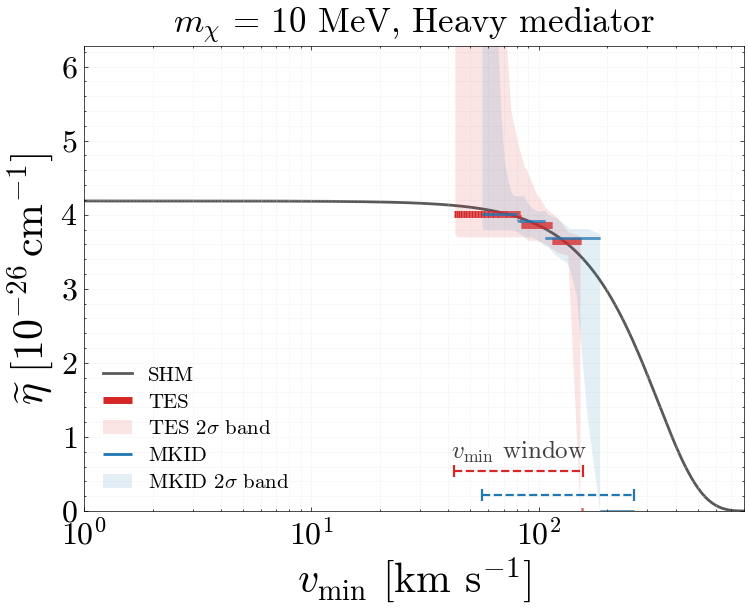

  saved results/final/Halo/heavy/R5/M2_band2s.pdf


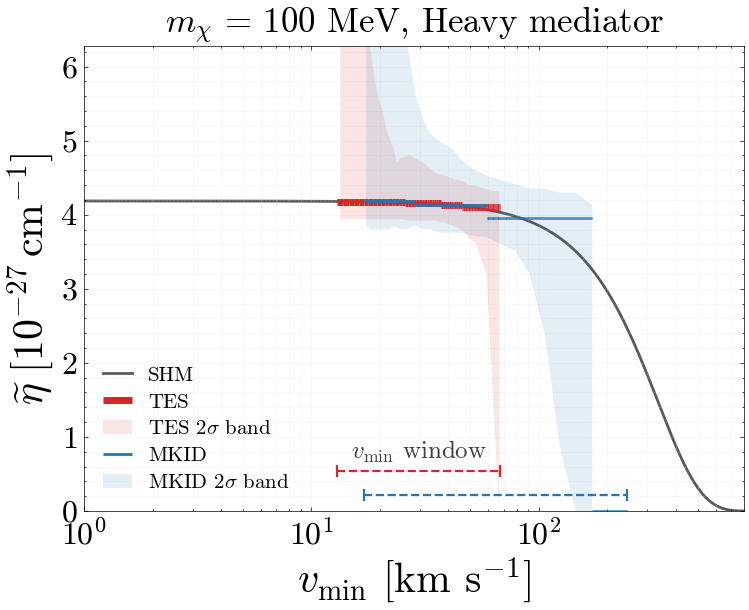

  saved results/final/Halo/heavy/R5/M3_band2s.pdf


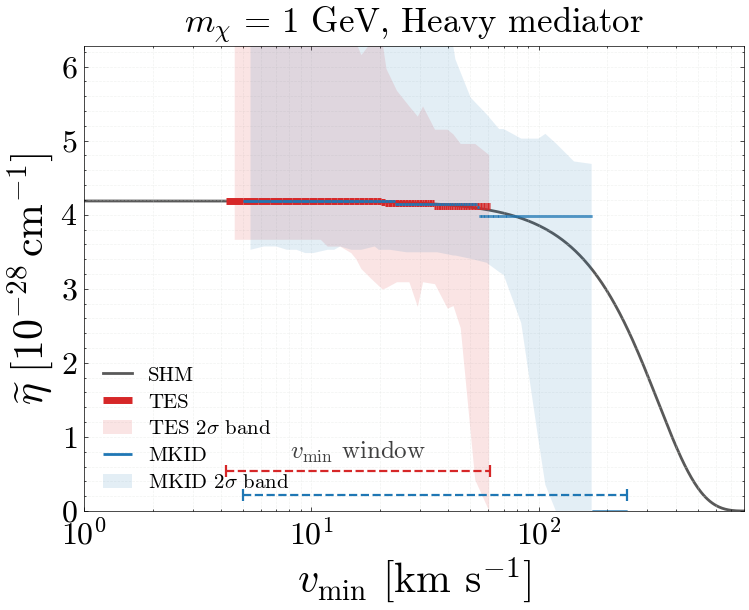

In [86]:
final_all(q='0', eta='Halo', band_2sigma=True)

### Light mediator (q2)

  saved results/final/Halo/light/R5/M1.pdf


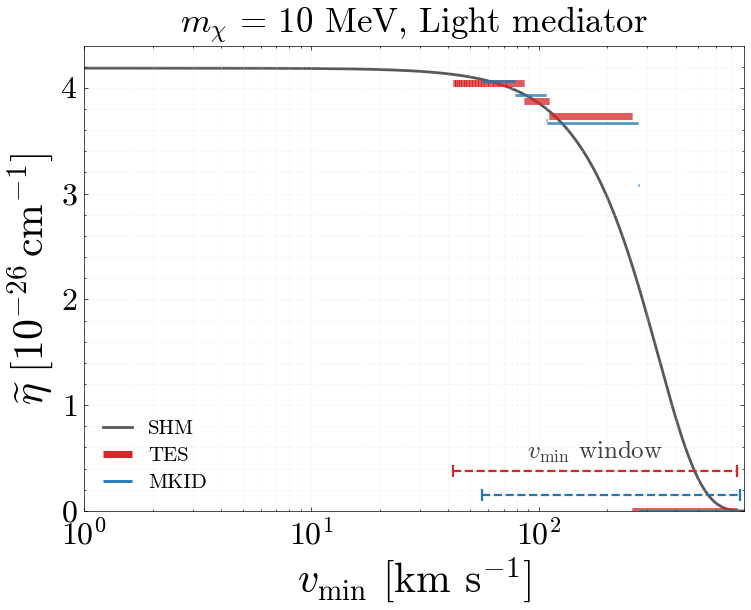

  saved results/final/Halo/light/R5/M2.pdf


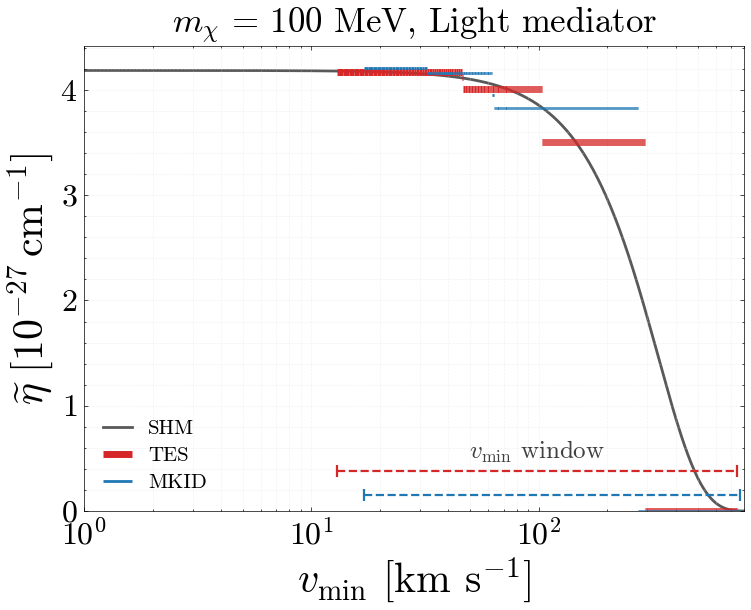

  saved results/final/Halo/light/R5/M3.pdf


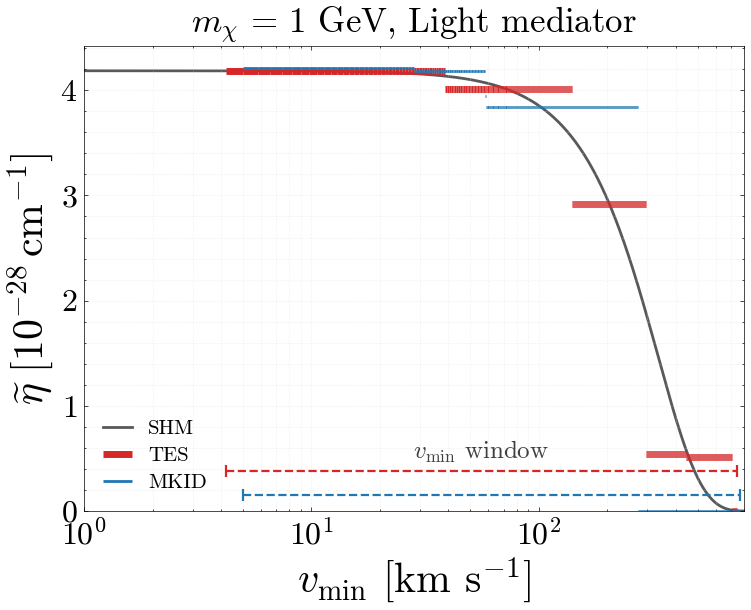

In [54]:
final_all(q='2', eta='Halo')

## Halo (SHM) — each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0)

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M1.pdf


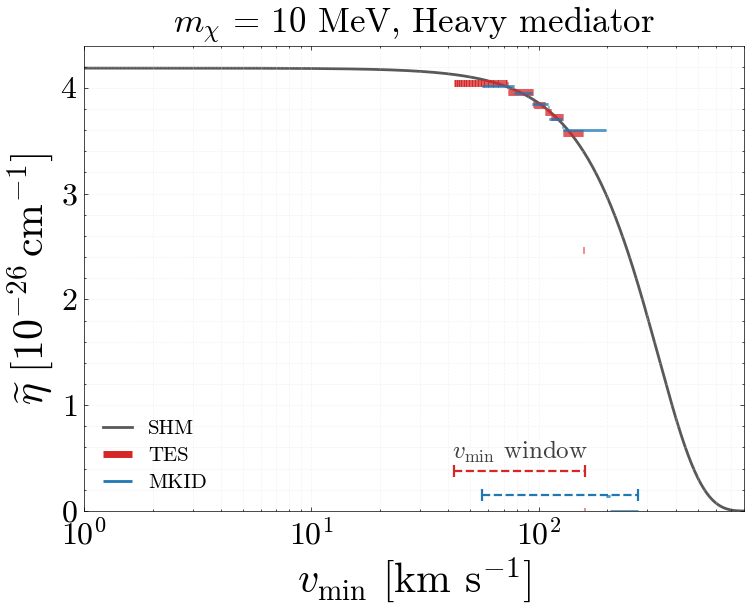

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M2.pdf


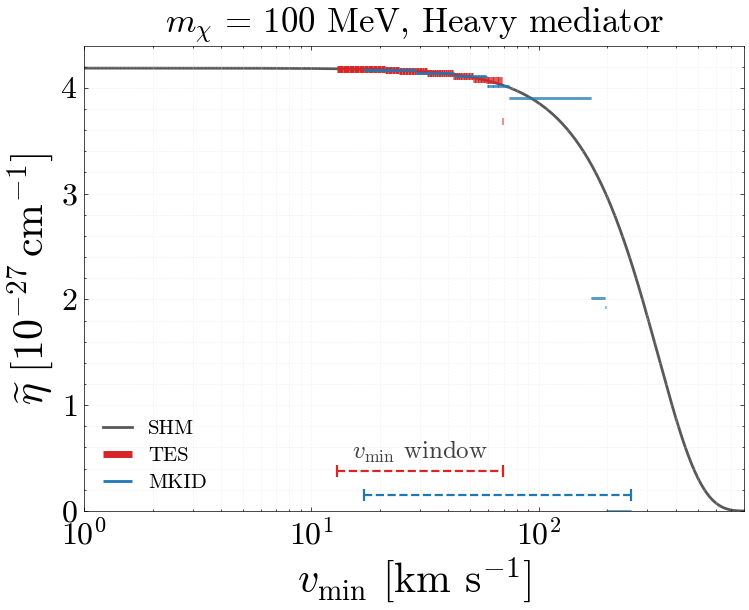

  saved results/final/Halo/heavy/TES-R10_MKID-R9/M3.pdf


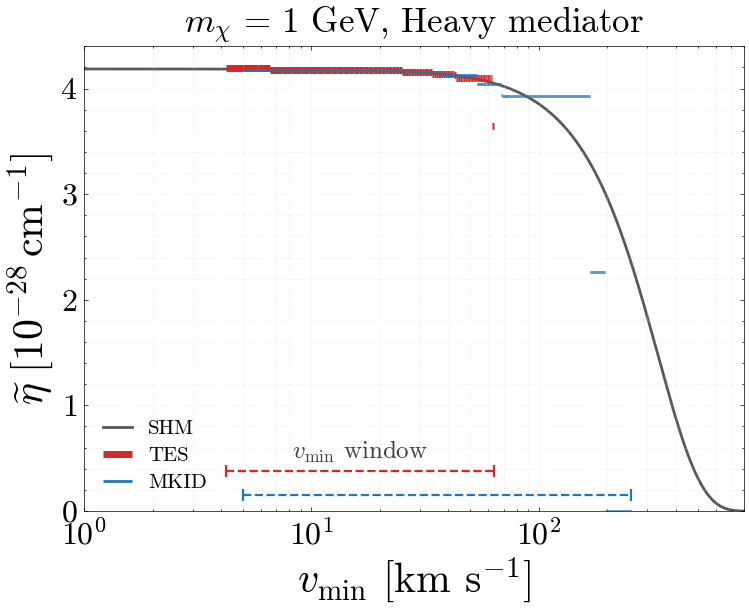

In [55]:
final_all(q='0', eta='Halo', tes_nbins=10, mkid_nbins=9)

### Light mediator (q2)
MKID q2 R9 must be generated first; it is skipped with a note if absent.

  saved results/final/Halo/light/TES-R10_MKID-R9/M1.pdf


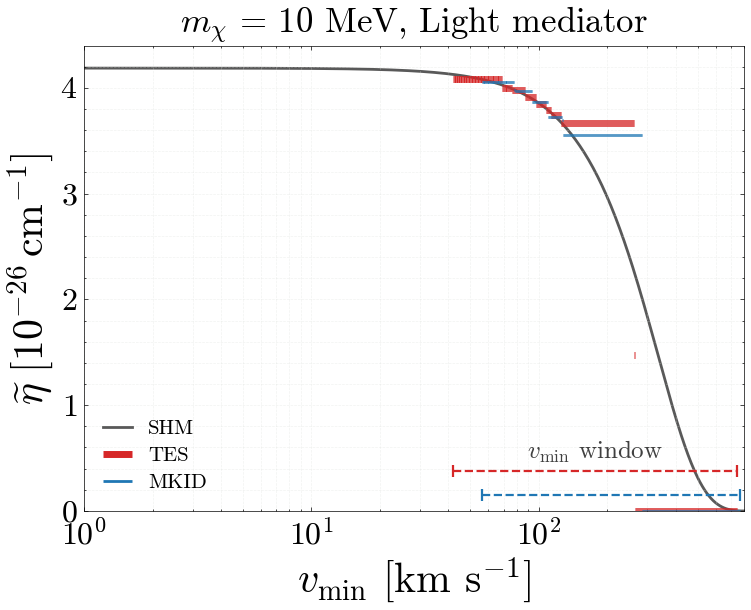

  saved results/final/Halo/light/TES-R10_MKID-R9/M2.pdf


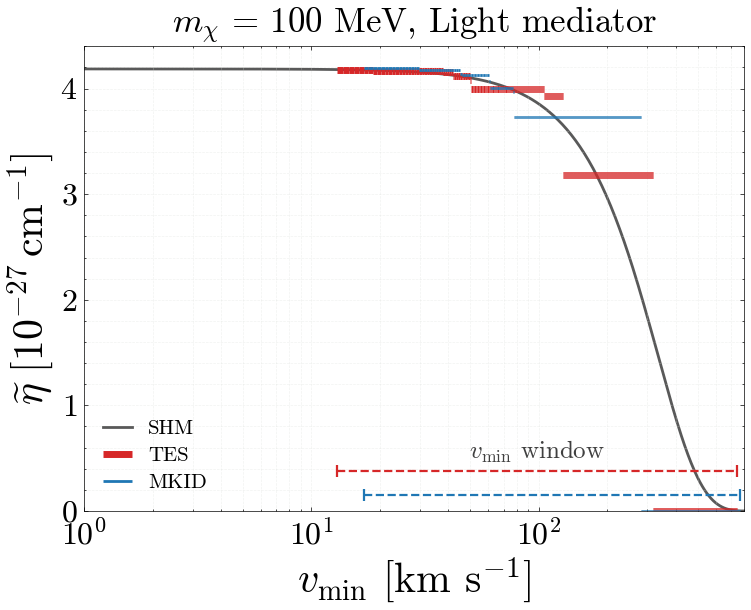

  saved results/final/Halo/light/TES-R10_MKID-R9/M3.pdf


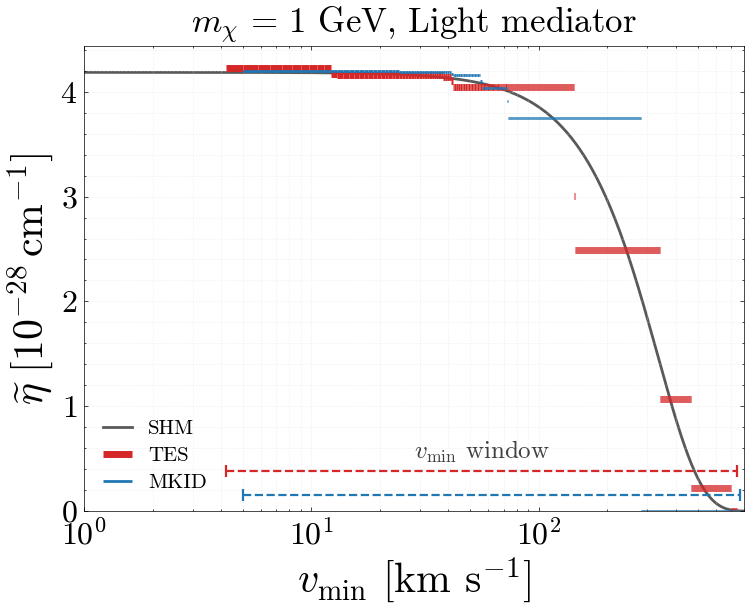

In [56]:
final_all(q='2', eta='Halo', tes_nbins=10, mkid_nbins=9)

## Mixture (best-fit) — dark-disk fraction, R5

### Heavy mediator (q0), 5% disk

  saved results/final/mix5/heavy/R5/M1_band2s.pdf


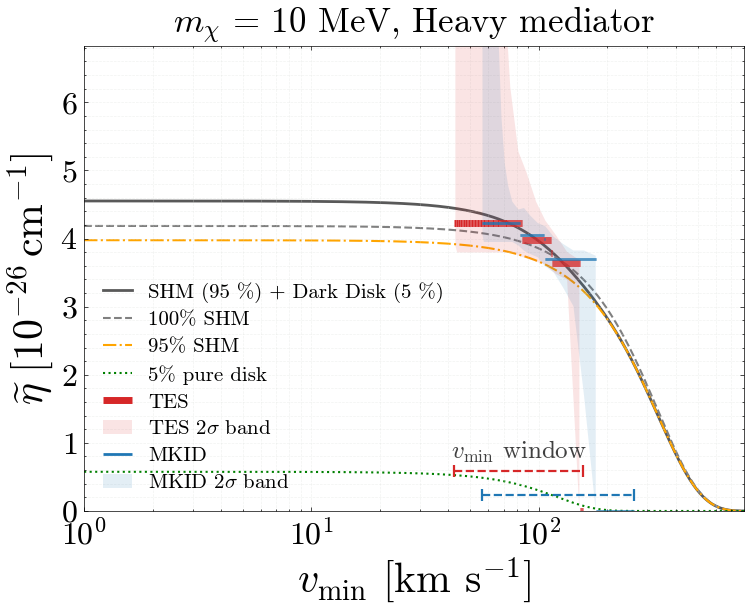

  saved results/final/mix5/heavy/R5/M2_band2s.pdf


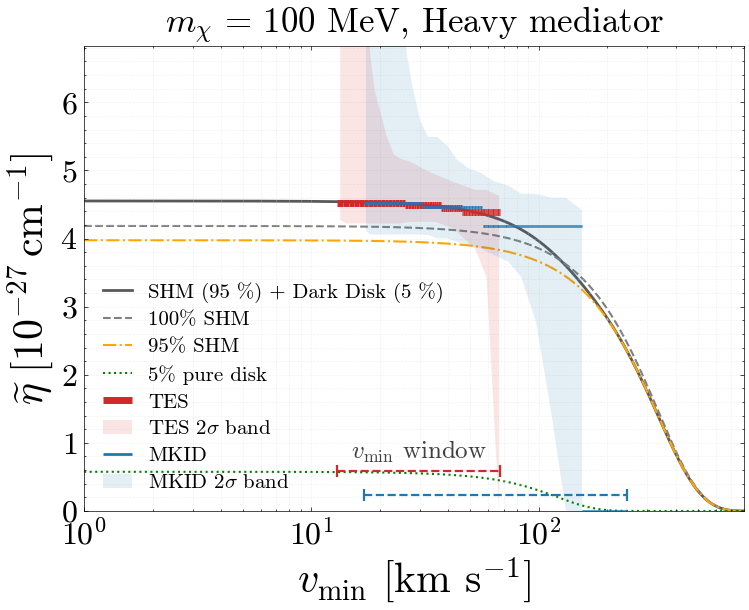

  skip MKID band: no band/ JSONs under TiN_q0_M3_R5_mix5
  saved results/final/mix5/heavy/R5/M3_band2s.pdf


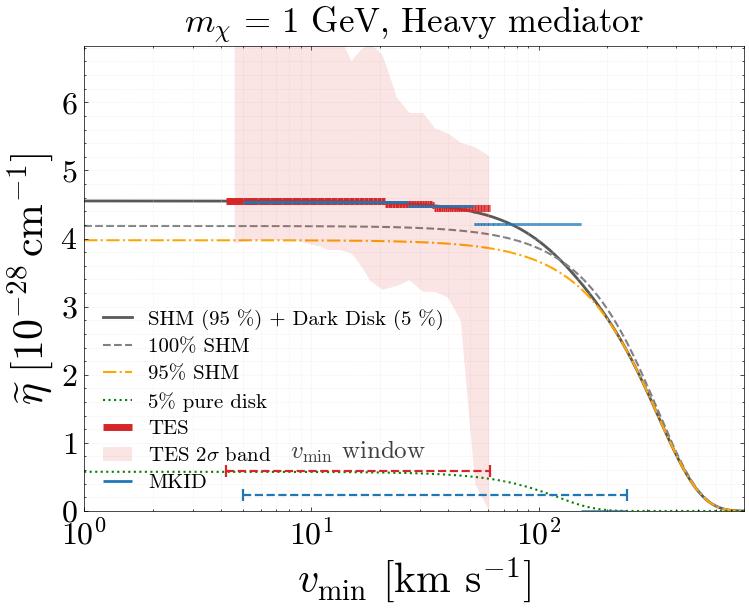

In [74]:
final_all(q='0', eta='Halo', disk_fraction=0.05, band_2sigma=True)

### Heavy mediator (q0), 25% disk

  saved results/final/mix25/heavy/R5/M1_band2s.pdf


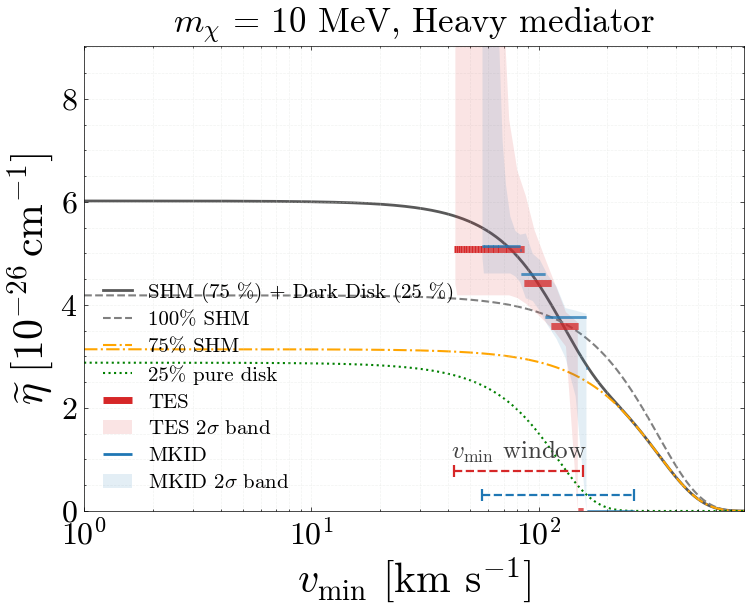

  saved results/final/mix25/heavy/R5/M2_band2s.pdf


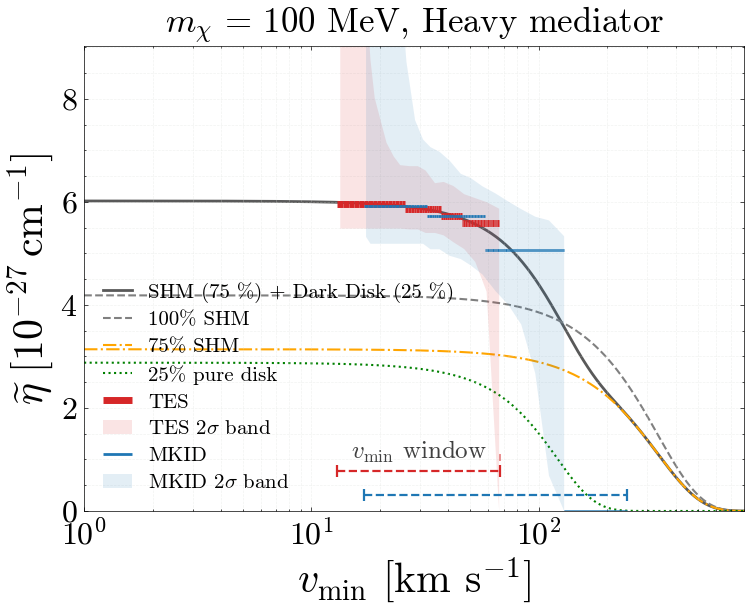

  skip MKID band: no band/ JSONs under TiN_q0_M3_R5_mix25
  saved results/final/mix25/heavy/R5/M3_band2s.pdf


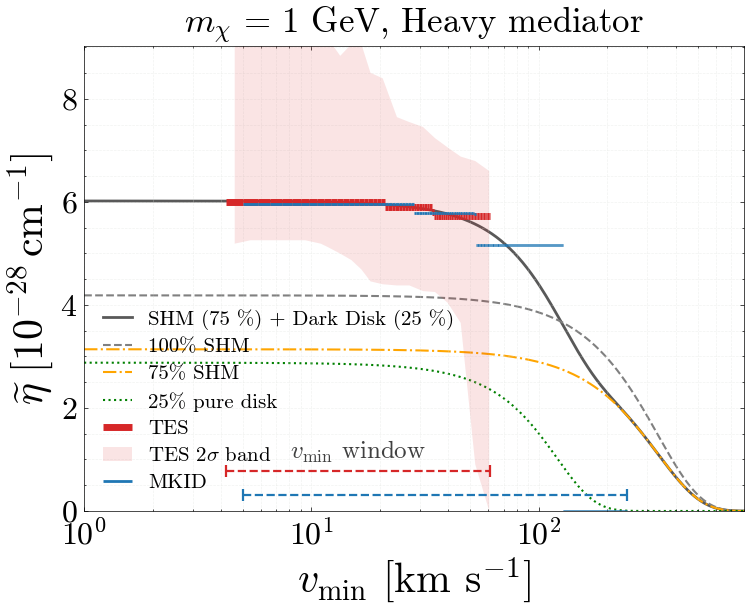

In [81]:
final_all(q='0', eta='Halo', disk_fraction=0.25, band_2sigma=True)

### Light mediator (q2), 5% disk

  saved results/final/mix5/light/R5/M1.pdf


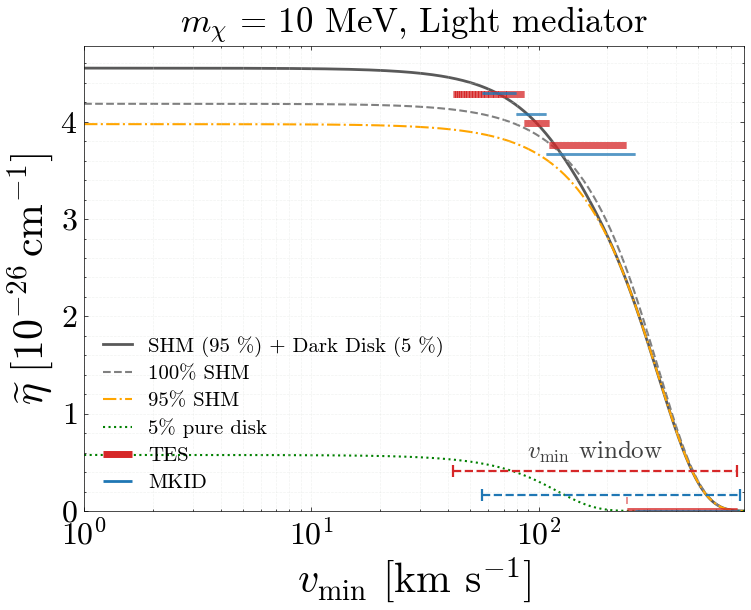

  saved results/final/mix5/light/R5/M2.pdf


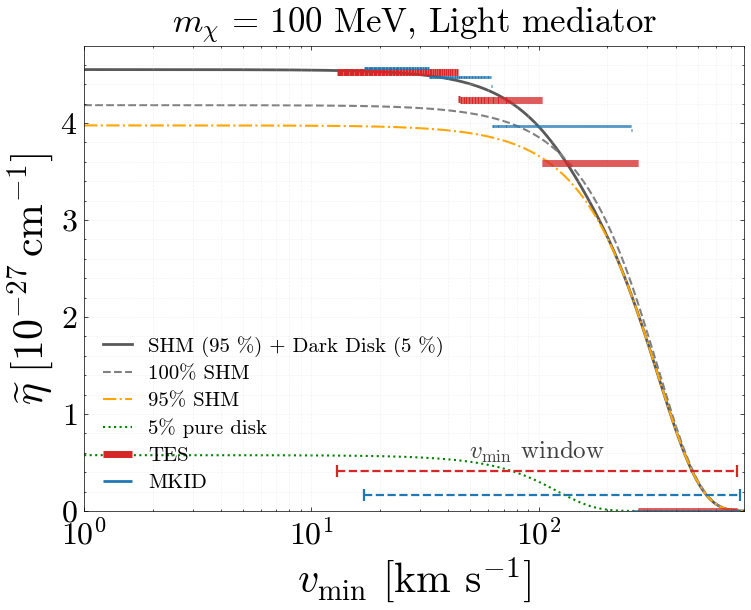

  saved results/final/mix5/light/R5/M3.pdf


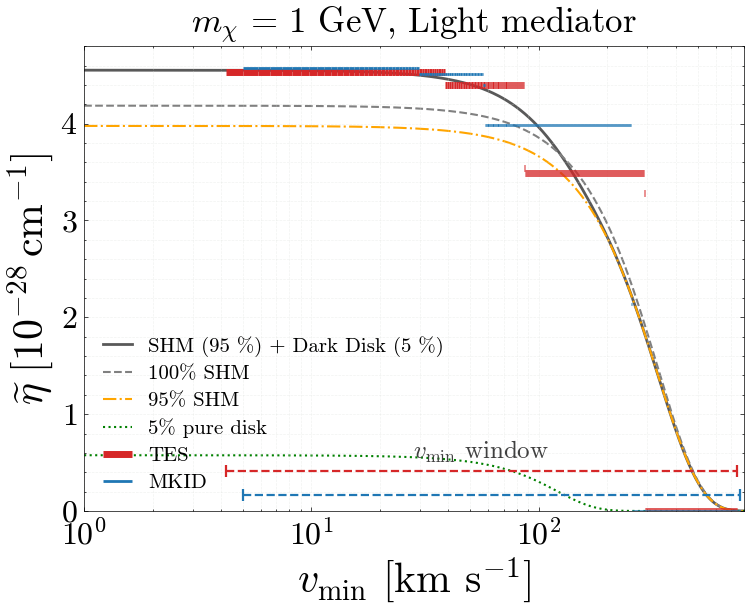

In [60]:
final_all(q='2', eta='Halo', disk_fraction=0.05)

### Light mediator (q2), 25% disk

  saved results/final/mix25/light/R5/M1.pdf


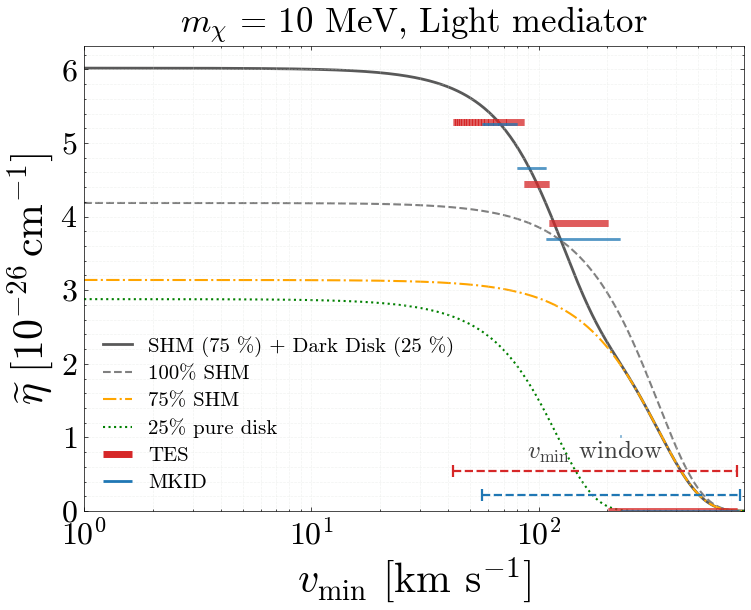

  saved results/final/mix25/light/R5/M2.pdf


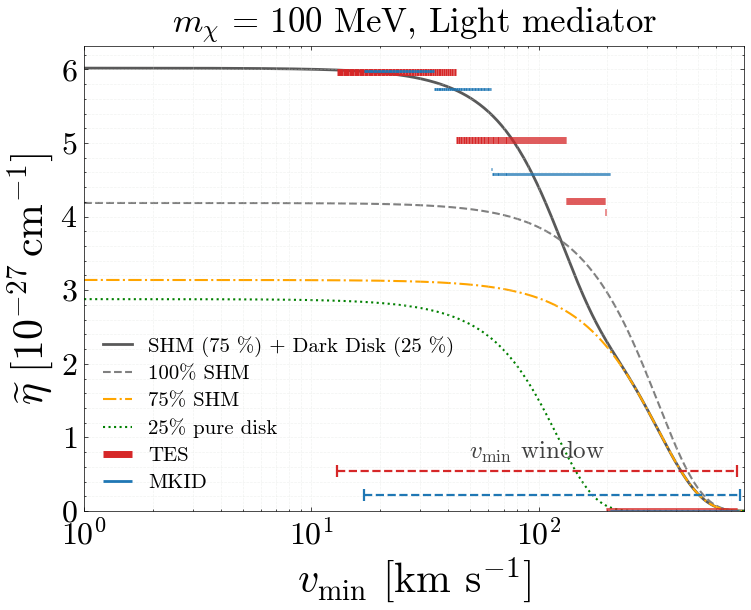

  saved results/final/mix25/light/R5/M3.pdf


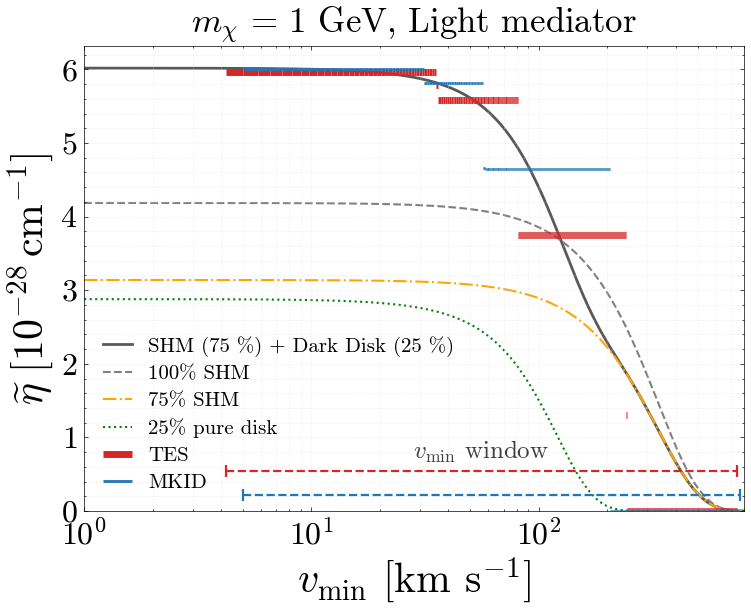

In [61]:
final_all(q='2', eta='Halo', disk_fraction=0.25)

## Mixture (best-fit) — dark-disk fraction each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0), 5% disk

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M1.pdf


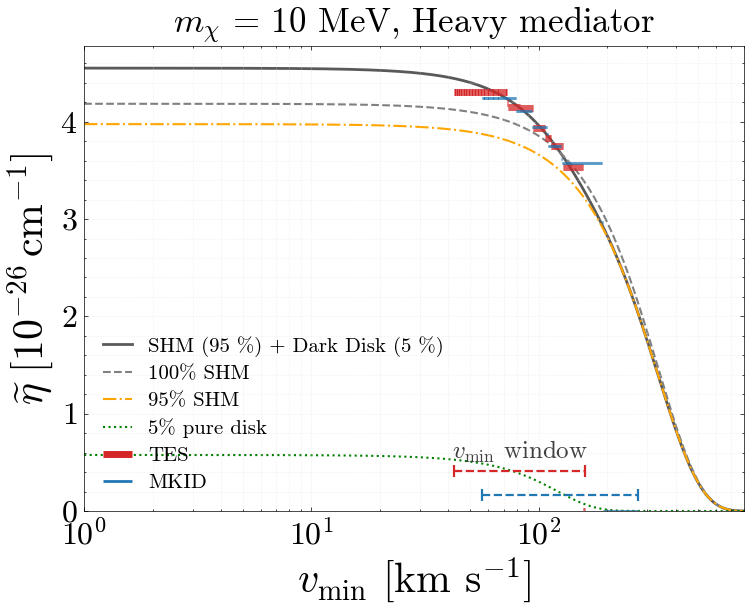

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M2.pdf


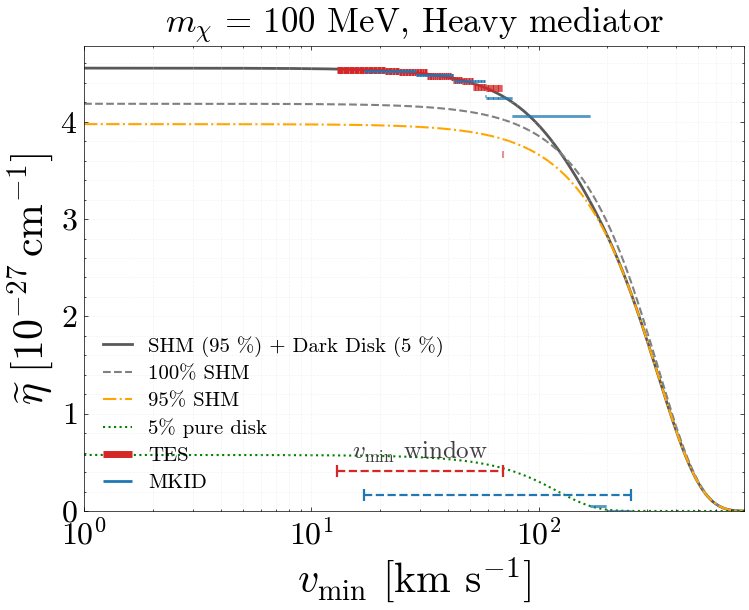

  saved results/final/mix5/heavy/TES-R10_MKID-R9/M3.pdf


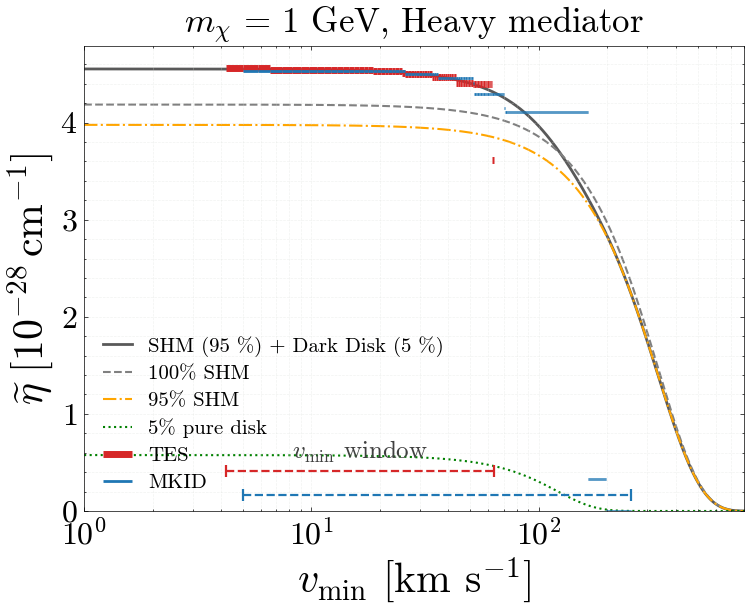

In [62]:
final_all(q='0', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

### Heavy mediator (q0), 25% disk

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M1.pdf


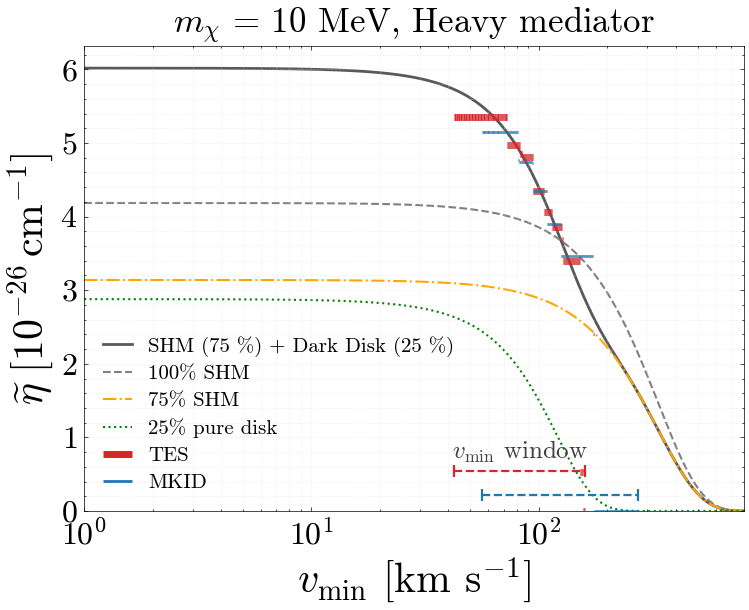

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M2.pdf


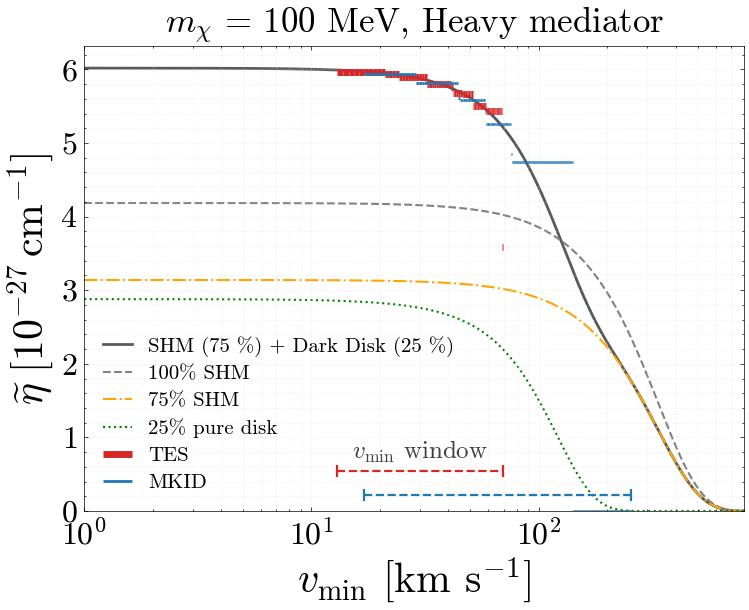

  saved results/final/mix25/heavy/TES-R10_MKID-R9/M3.pdf


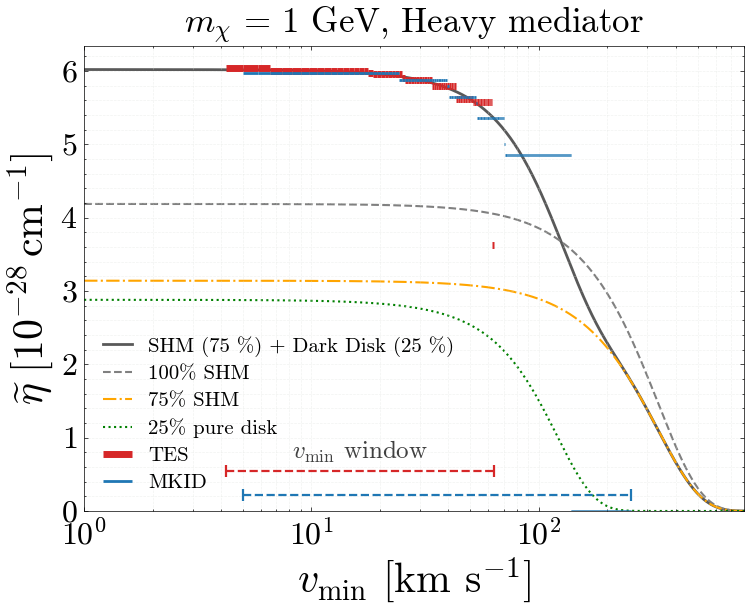

In [63]:
final_all(q='0', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

### Light mediator (q2), 5% disk

  saved results/final/mix5/light/TES-R10_MKID-R9/M1.pdf


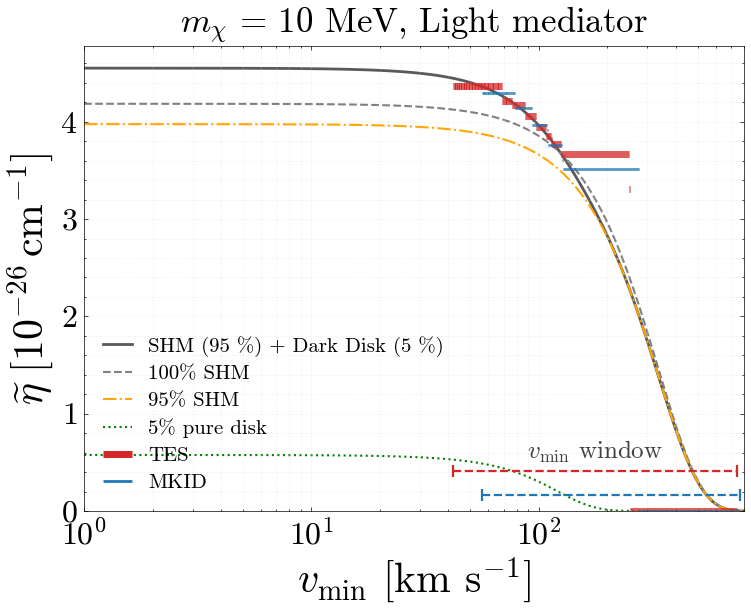

  saved results/final/mix5/light/TES-R10_MKID-R9/M2.pdf


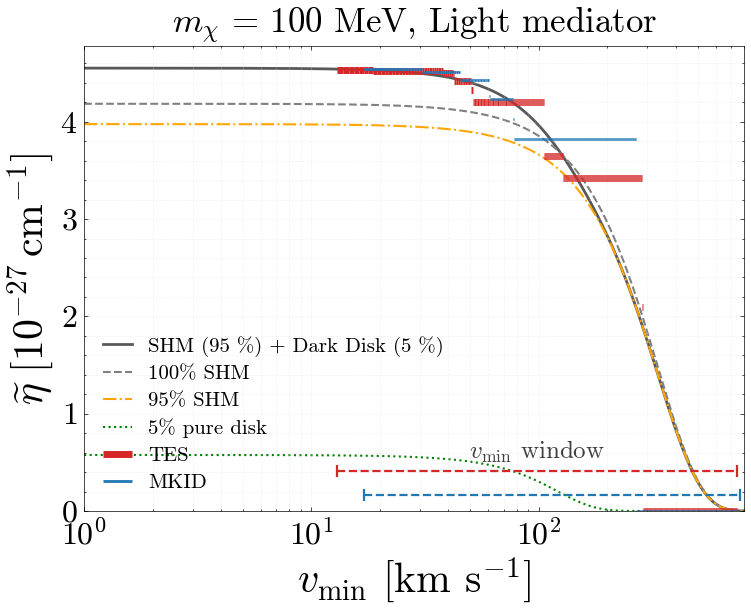

  saved results/final/mix5/light/TES-R10_MKID-R9/M3.pdf


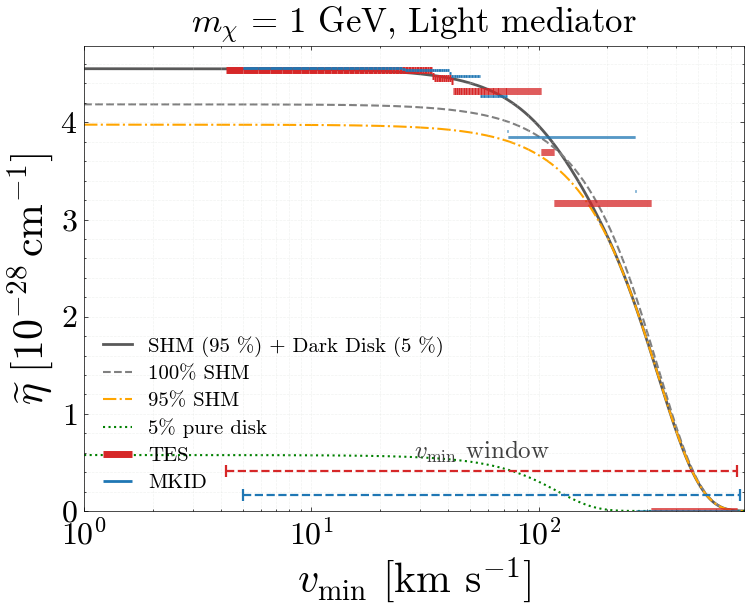

In [64]:
final_all(q='2', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

### Light mediator (q2), 25% disk

  saved results/final/mix25/light/TES-R10_MKID-R9/M1.pdf


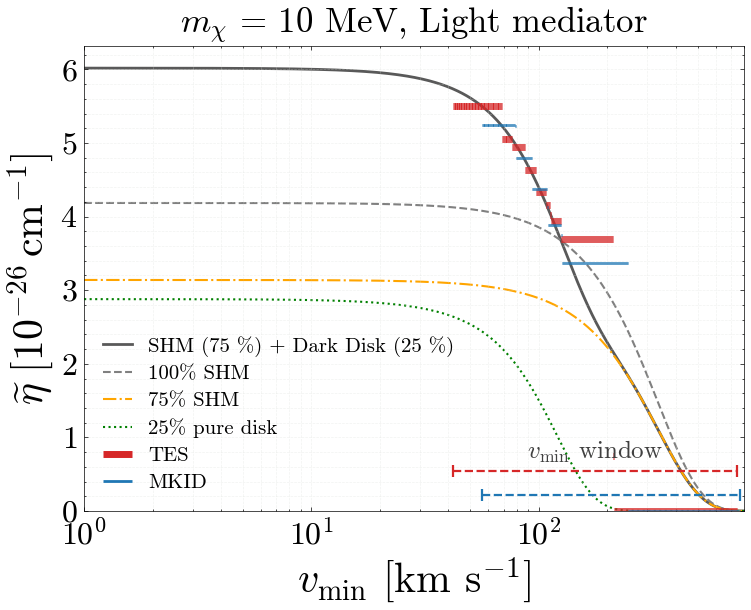

  saved results/final/mix25/light/TES-R10_MKID-R9/M2.pdf


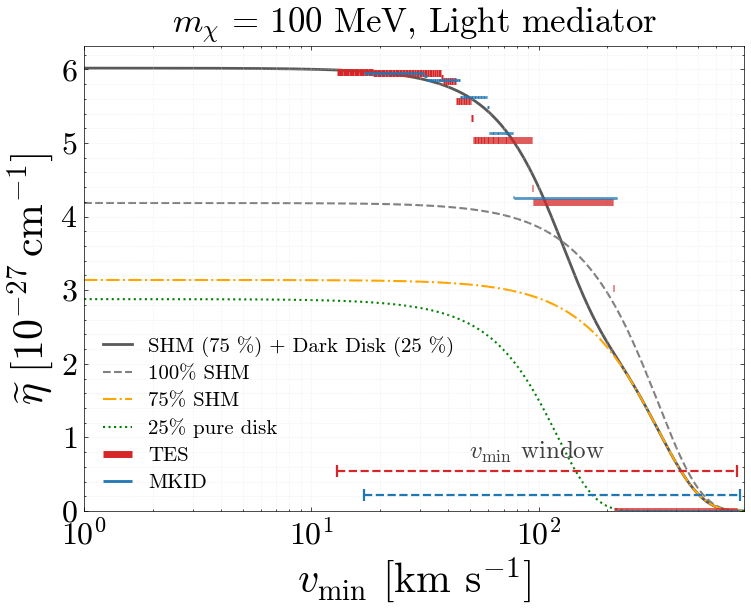

  saved results/final/mix25/light/TES-R10_MKID-R9/M3.pdf


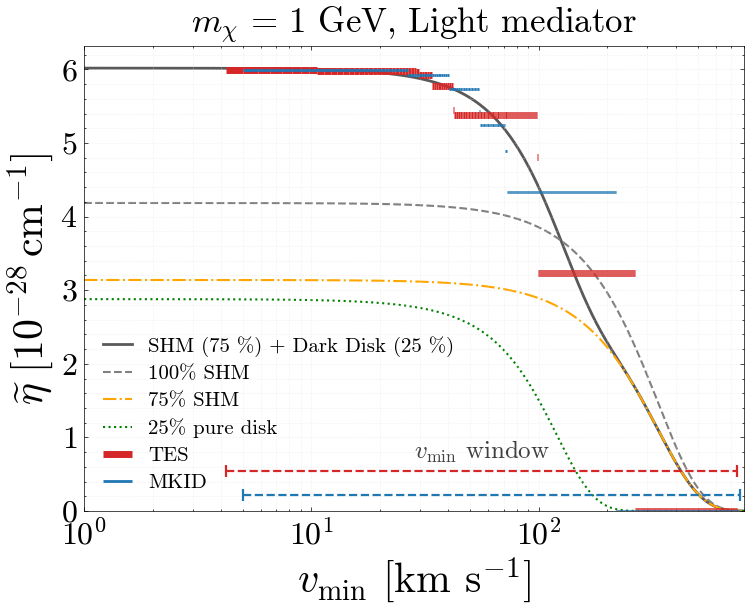

In [65]:
final_all(q='2', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

## Bound (Earth-bound thermal DM) — only the heaviest mass (1 GeV) reaches the window

### Heavy mediator (q0), R5

  saved results/final/Bound/heavy/R5/M3.pdf


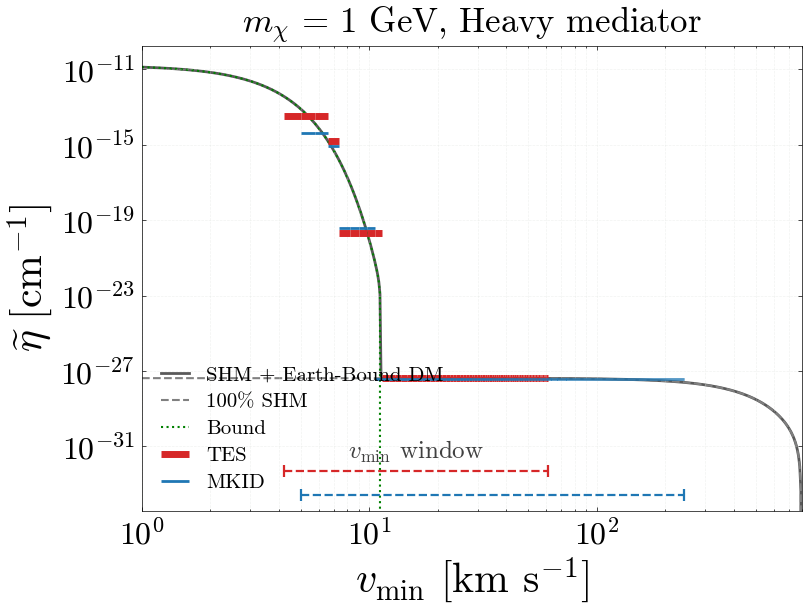

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Heavy mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [84]:
final_figure(q='0', eta='Bound', mass='3')

### Light mediator (q2), R5

  saved results/final/Bound/light/R5/M3.pdf


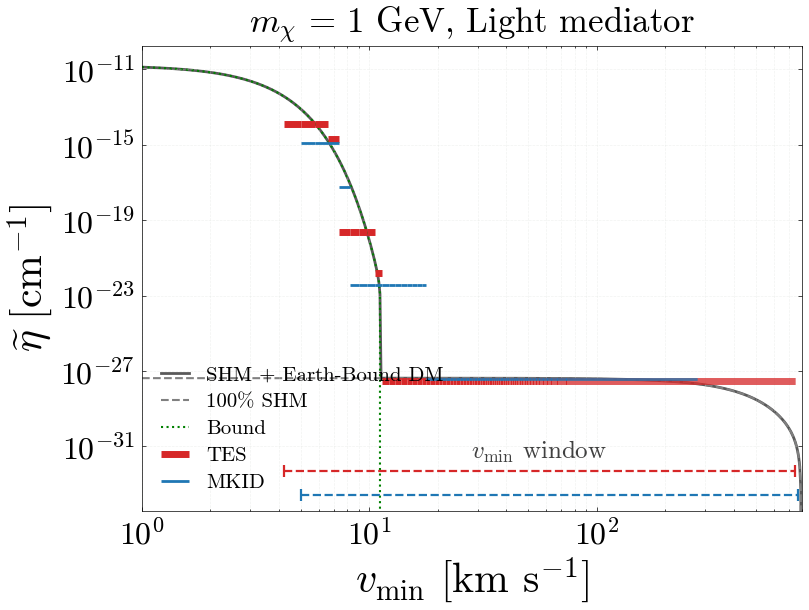

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Light mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [67]:
final_figure(q='2', eta='Bound', mass='3')

## Bound (Earth-bound thermal DM) — only the heaviest mass (1 GeV) reaches the window each detector's fine binning (TES R10 / MKID R9)

### Heavy mediator (q0)

  saved results/final/Bound/heavy/TES-R10_MKID-R9/M3.pdf


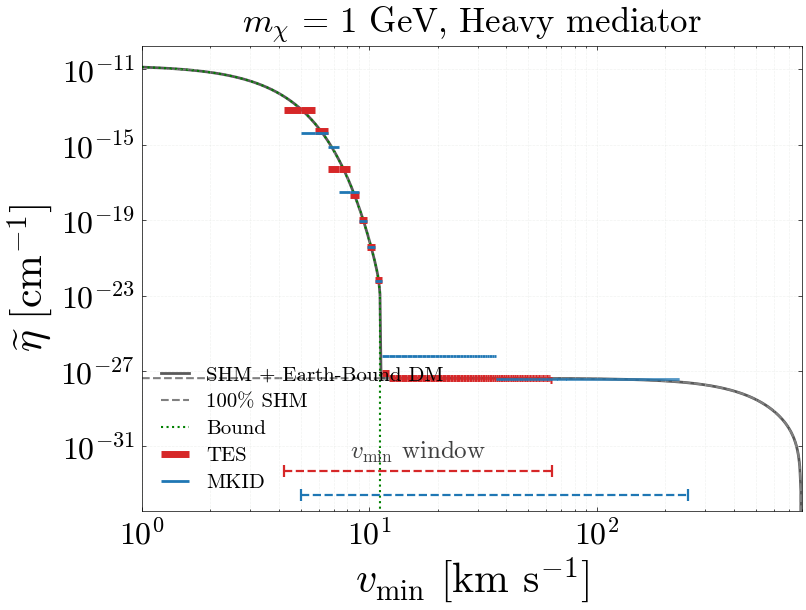

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Heavy mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [18]:
final_figure(q='0', eta='Bound', mass='3', tes_nbins=10, mkid_nbins=9)

### Light mediator (q2)

  saved results/final/Bound/light/TES-R10_MKID-R9/M3.pdf


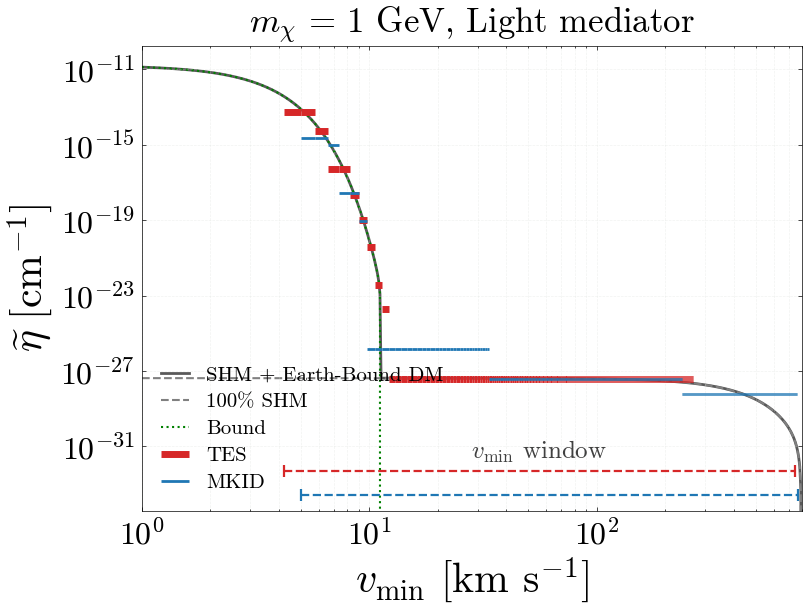

<Axes: title={'center': '$m_\\chi$ = 1 GeV, Light mediator'}, xlabel='$v_{\\text{min}}$ [km s$^{-1}$]', ylabel='$\\widetilde{\\eta}\\ [\\mathrm{cm}^{-1}]$'>

In [19]:
final_figure(q='2', eta='Bound', mass='3', tes_nbins=10, mkid_nbins=9)

# Per-bin expected signal $\langle N_{\text{event}} \rangle$

Forward-model expected counts per $E'$ bin, comparing **detectors** (TES red / MKID blue) and **DM masses** (separating vertically) in one figure. Saved under `results/final/signal/<scenario>/<heavy|light>/<binning>.pdf`.

In [20]:
SCENARIO_TITLE = {"Halo": "SHM", "Disk": "Dark disk", "Bound": "SHM + Earth-Bound DM"}
# DM mass -> line style for the per-bin signal segments.
MASS_LS = {"1": "-", "2": "--", "3": ":"}     # 10 MeV solid, 100 MeV dashed, 1 GeV dotted


def signal_figure(q, eta, disk_fraction=None, tes_nbins=5, mkid_nbins=5,
                  masses=("1", "2", "3"), background="none", save=True, outdir=OUTDIR):
    """Per-energy-bin expected signal <N_event> for TES vs MKID, all masses at once.

    Forward model only (no inversion): each detector/mass gives
    <N> = exposure x (M @ eta) per E' bin, drawn as a horizontal segment over
    [E_low, E_high] with a Poisson sqrt(N) error bar. Colour = detector; the DM
    masses separate vertically and are labelled at the right.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    nb = {"TES": tes_nbins, "MKID": mkid_nbins}
    for mass in masses:
        top = 0.0
        for det in ("TES", "MKID"):
            cfg = RunConfig(material=MATERIAL[det], q=q, mass=mass, nbins=nb[det],
                            eta=eta, disk_fraction=disk_fraction, background=background)
            try:
                a = DarkMatterQuantumAnalysis(cfg)
            except FileNotFoundError:
                print(f"  skip {det}: no matrix for q{q} M{mass} R{nb[det]} {eta}")
                continue
            s = a.signal
            lo, hi = a.rm.ebin_low, a.rm.ebin_high
            mid = 0.5 * (lo + hi)
            ax.hlines(s, lo, hi, color=STYLE[det]["color"], lw=STYLE[det]["lw"],
                      linestyles=MASS_LS.get(mass, "-"),
                      zorder=3, label=det if mass == masses[0] else None)
            ax.errorbar(mid, s, yerr=np.sqrt(s), fmt="none", ecolor=STYLE[det]["color"],
                        elinewidth=1.0, capsize=2, zorder=2)
            top = max(top, float(np.max(s)))
        if top > 0:
            ax.text(1.14, top, MASS_LABELS[mass], fontsize=18, va="center",
                    ha="left", color="0.2")

    ax.set_yscale("log")
    ax.set_xlim(0.05, 1.4)
    ax.set_ylim(bottom=1.0)
    ax.set_xlabel(r"$E'$ [eV]", fontsize=30)
    ax.set_ylabel(r"$\langle N_{\text{event}} \rangle$", fontsize=30)
    mediator = {"0": "Heavy", "2": "Light"}.get(q, f"q{q}")
    scen = (SCENARIO_TITLE.get(eta, eta) if disk_fraction is None
            else f"SHM ({round((1 - disk_fraction) * 100)} %) + Dark Disk ({round(disk_fraction * 100)} %)")
    ax.set_title(rf"{scen}, {mediator} mediator", fontsize=25)
    ax.tick_params(axis="both", which="major", labelsize=23)
    ax.tick_params(axis="both", which="minor", labelsize=23)
    ax.legend(loc="lower right", fontsize=15, frameon=False)
    ax.grid(True, which="both", ls="--", alpha=0.3)

    if save:
        scenario = eta if disk_fraction is None else f"mix{round(disk_fraction * 100)}"
        binning = (f"R{tes_nbins}" if tes_nbins == mkid_nbins
                   else f"TES-R{tes_nbins}_MKID-R{mkid_nbins}")
        dest = outdir / "signal" / scenario / mediator.lower()
        dest.mkdir(parents=True, exist_ok=True)
        path = dest / f"{binning}.pdf"
        plt.savefig(path, bbox_inches="tight")
        print(f"  saved {path.relative_to(RESULTS_DIR.parent)}")
    plt.show()
    return ax

## SHM (Halo) — common R5

  saved results/final/signal/Halo/heavy/R5.pdf


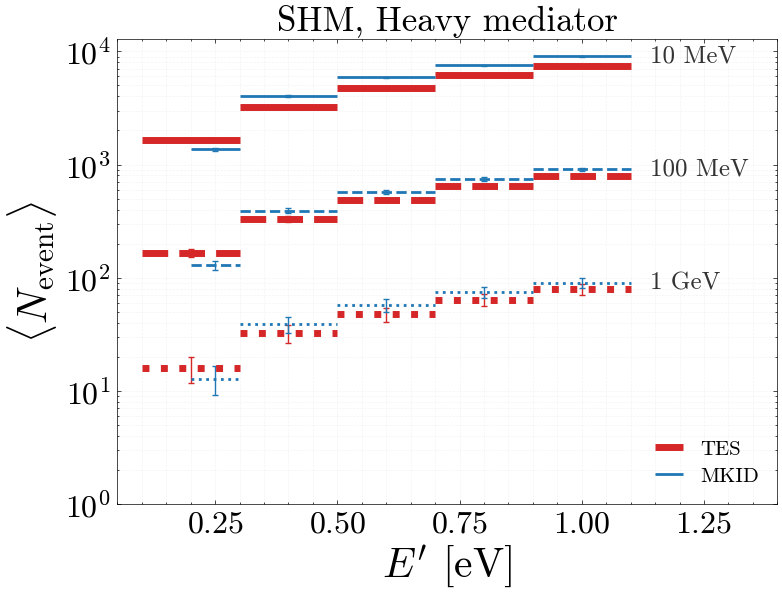

<Axes: title={'center': 'SHM, Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [21]:
signal_figure(q='0', eta='Halo')

  saved results/final/signal/Halo/light/R5.pdf


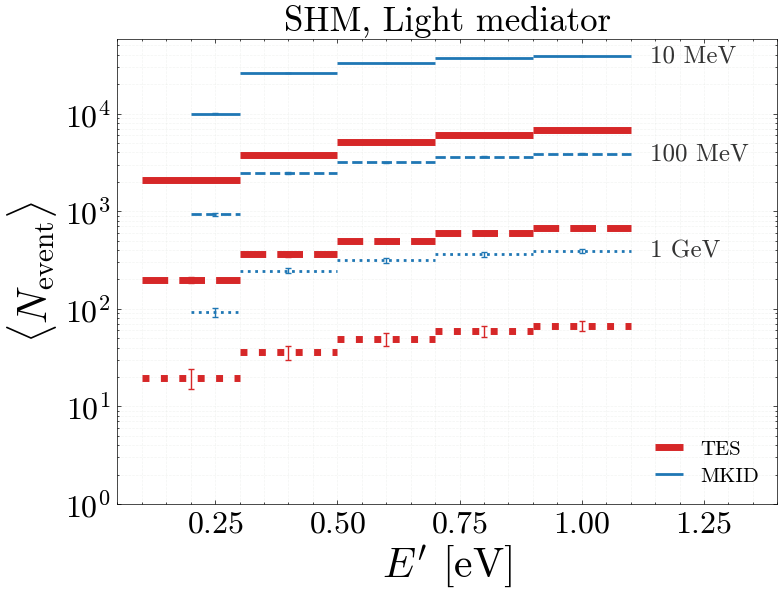

<Axes: title={'center': 'SHM, Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [22]:
signal_figure(q='2', eta='Halo')

## SHM (Halo) — fine binning (TES R10 / MKID R9)

  saved results/final/signal/Halo/heavy/TES-R10_MKID-R9.pdf


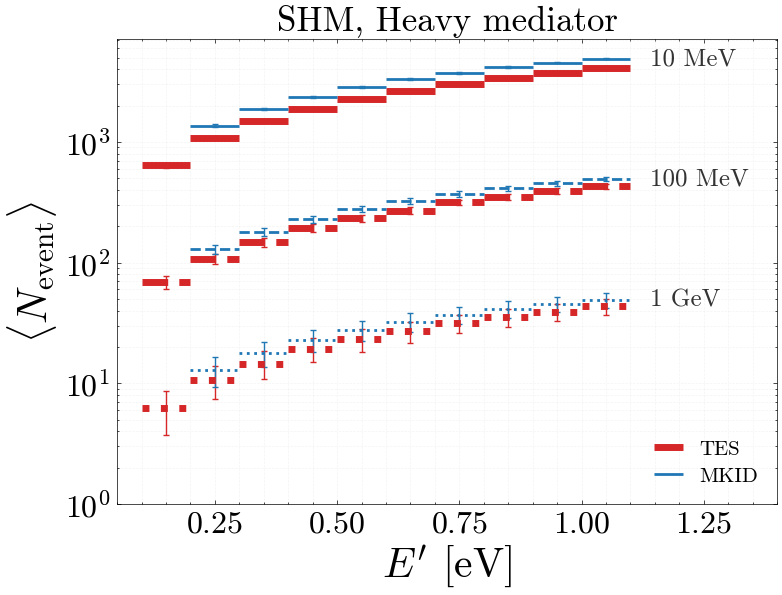

<Axes: title={'center': 'SHM, Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [23]:
signal_figure(q='0', eta='Halo', tes_nbins=10, mkid_nbins=9)

  saved results/final/signal/Halo/light/TES-R10_MKID-R9.pdf


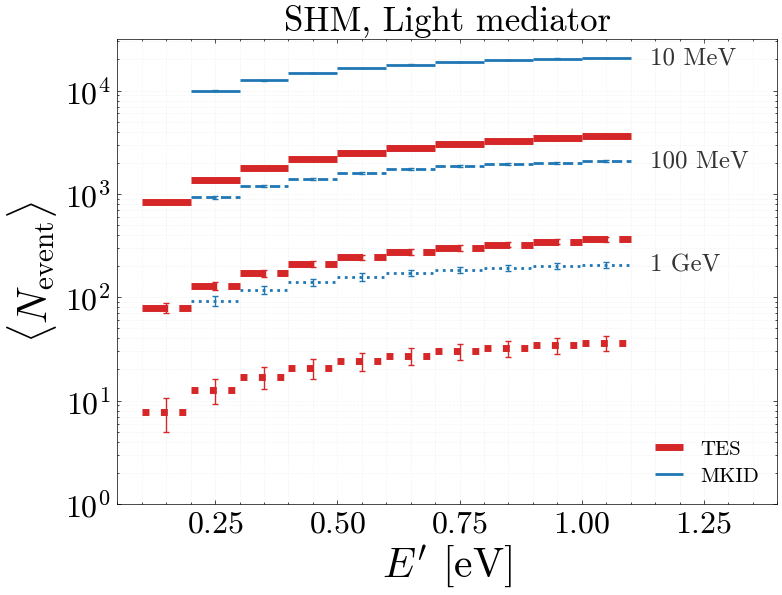

<Axes: title={'center': 'SHM, Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [24]:
signal_figure(q='2', eta='Halo', tes_nbins=10, mkid_nbins=9)

## Disk — common R5

  saved results/final/signal/mix5/heavy/R5.pdf


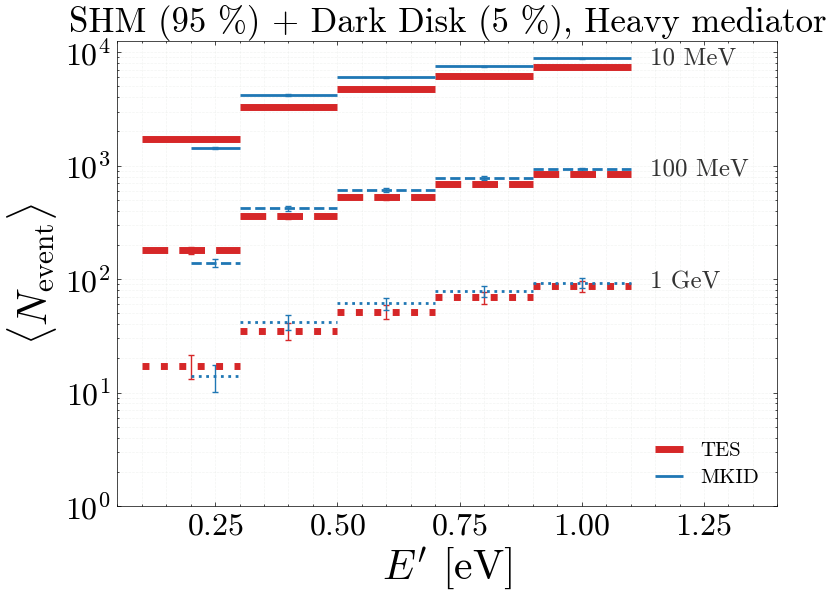

<Axes: title={'center': 'SHM (95 %) + Dark Disk (5 %), Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [25]:
signal_figure(q='0', eta='Halo', disk_fraction=0.05)

  saved results/final/signal/mix5/light/R5.pdf


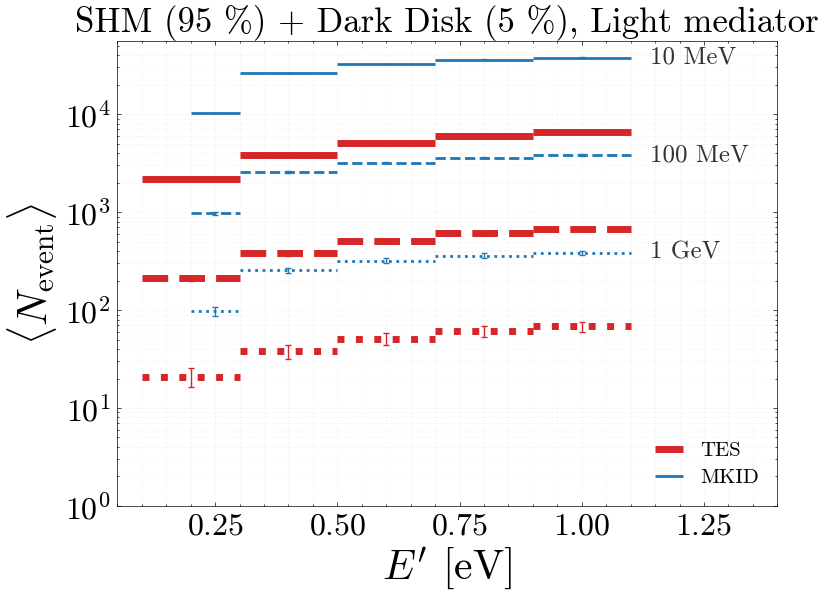

<Axes: title={'center': 'SHM (95 %) + Dark Disk (5 %), Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [26]:
signal_figure(q='2', eta='Halo', disk_fraction=0.05)

  saved results/final/signal/mix25/heavy/R5.pdf


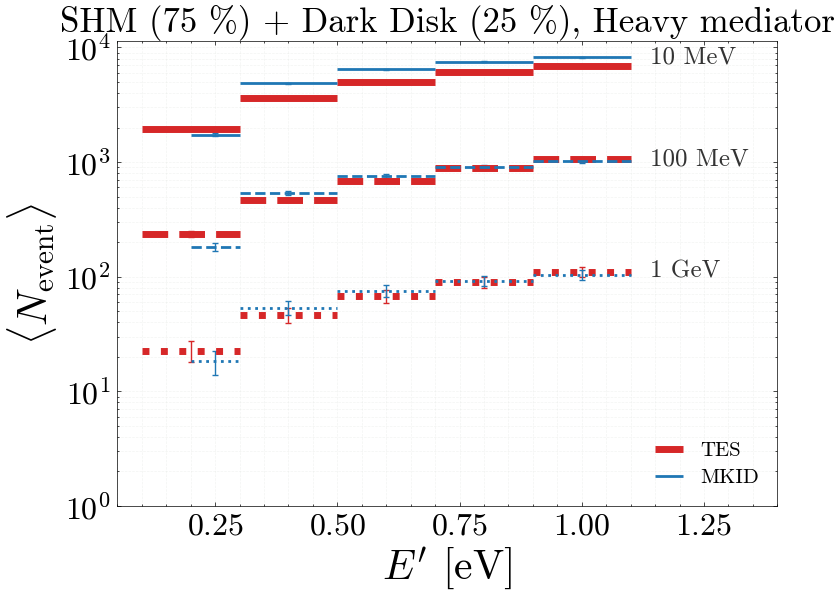

<Axes: title={'center': 'SHM (75 %) + Dark Disk (25 %), Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [27]:
signal_figure(q='0', eta='Halo', disk_fraction=0.25)

  saved results/final/signal/mix25/light/R5.pdf


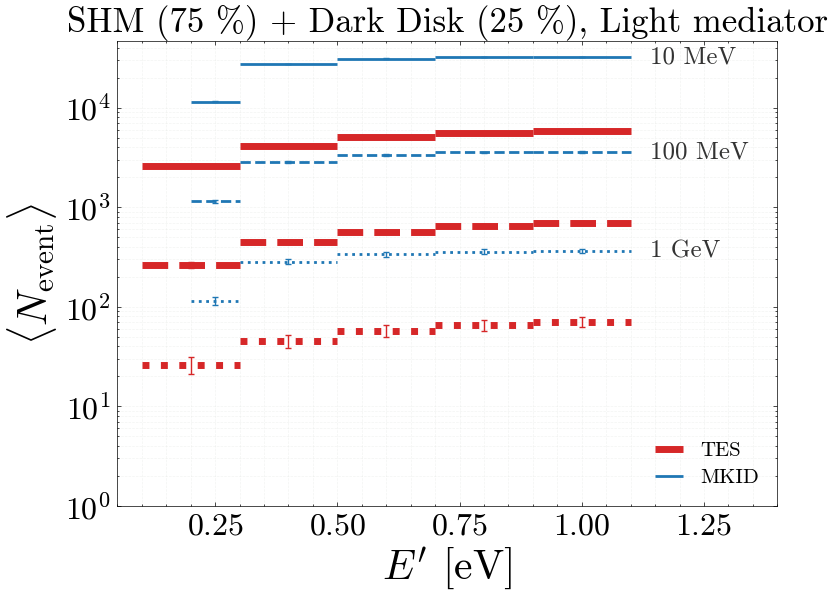

<Axes: title={'center': 'SHM (75 %) + Dark Disk (25 %), Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [28]:
signal_figure(q='2', eta='Halo', disk_fraction=0.25)

## Disk — fine binning

  saved results/final/signal/mix5/heavy/TES-R10_MKID-R9.pdf


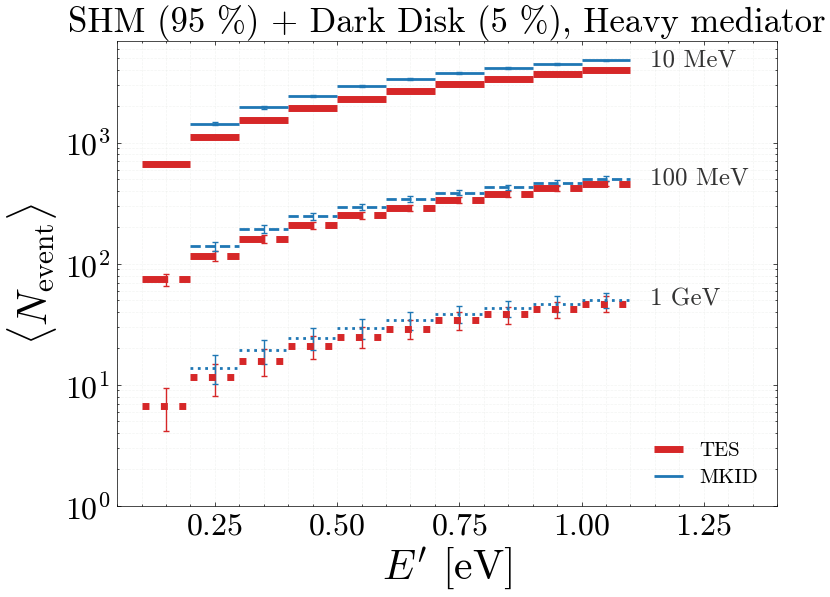

<Axes: title={'center': 'SHM (95 %) + Dark Disk (5 %), Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [29]:
signal_figure(q='0', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

  saved results/final/signal/mix5/light/TES-R10_MKID-R9.pdf


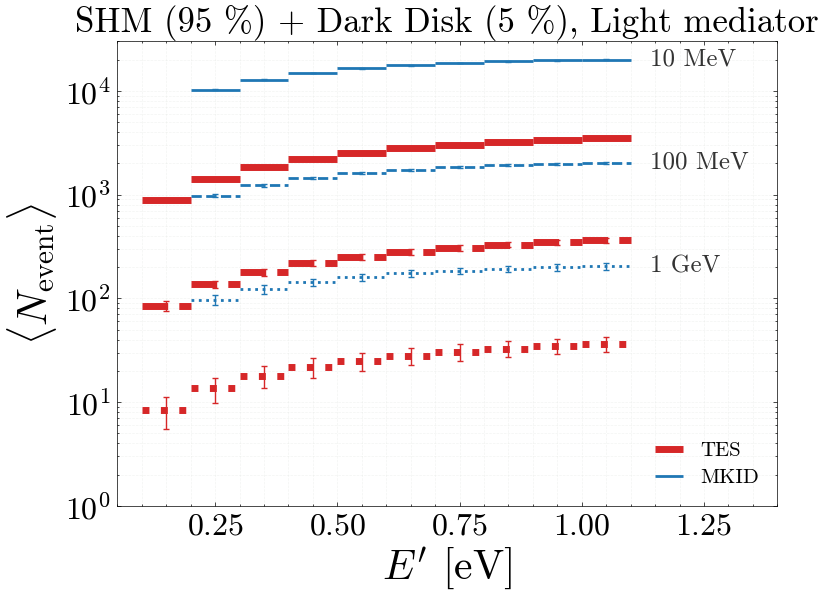

<Axes: title={'center': 'SHM (95 %) + Dark Disk (5 %), Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [30]:
signal_figure(q='2', eta='Halo', disk_fraction=0.05, tes_nbins=10, mkid_nbins=9)

  saved results/final/signal/mix25/heavy/TES-R10_MKID-R9.pdf


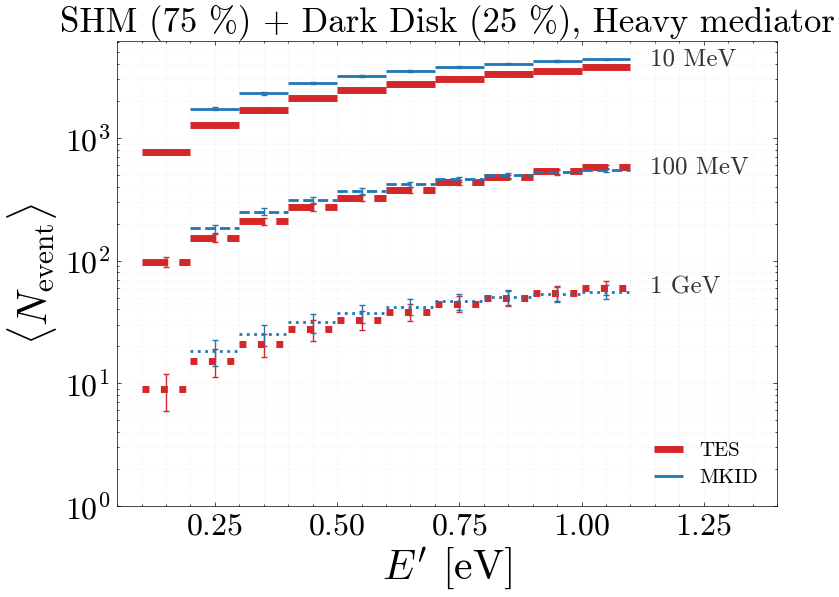

<Axes: title={'center': 'SHM (75 %) + Dark Disk (25 %), Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [31]:
signal_figure(q='0', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

  saved results/final/signal/mix25/light/TES-R10_MKID-R9.pdf


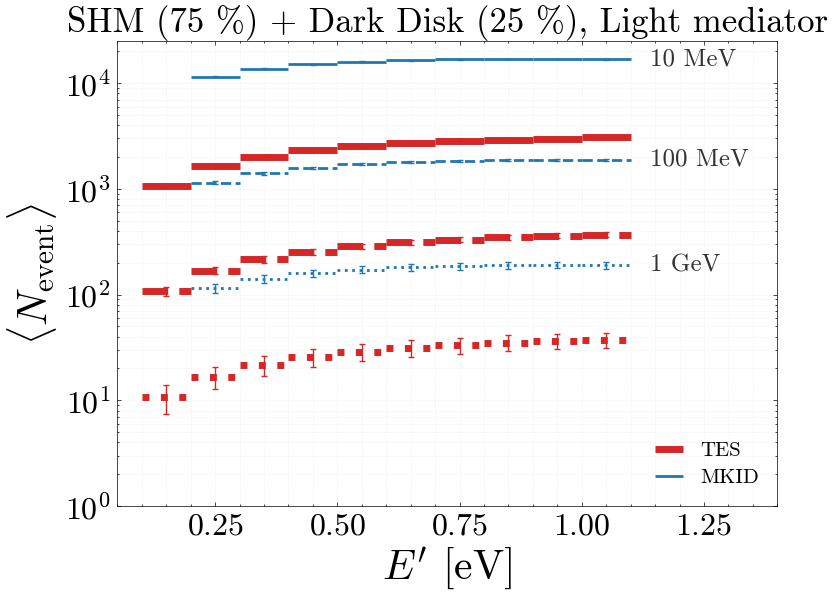

<Axes: title={'center': 'SHM (75 %) + Dark Disk (25 %), Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [32]:
signal_figure(q='2', eta='Halo', disk_fraction=0.25, tes_nbins=10, mkid_nbins=9)

## Bound — common R5

  saved results/final/signal/Bound/heavy/R5.pdf


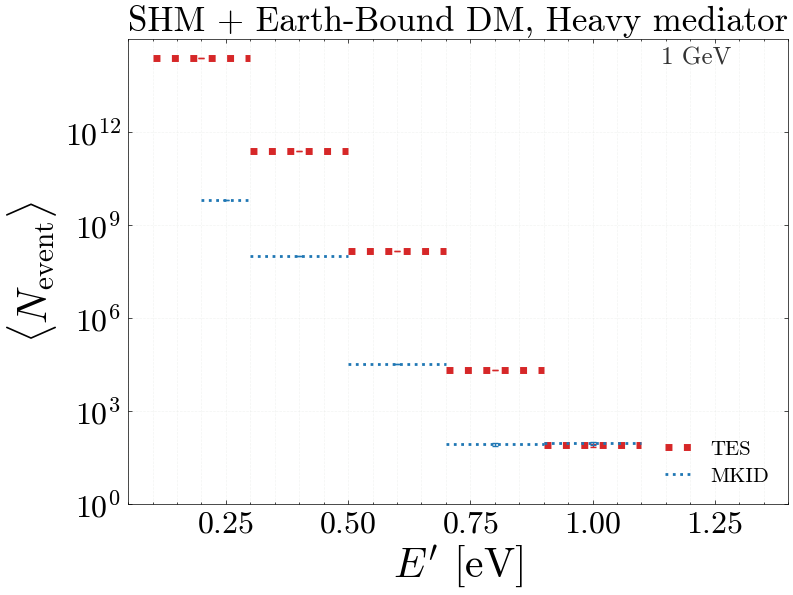

<Axes: title={'center': 'SHM + Earth-Bound DM, Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [33]:
signal_figure(q='0', eta='Bound', masses = ("3"))

  saved results/final/signal/Bound/light/R5.pdf


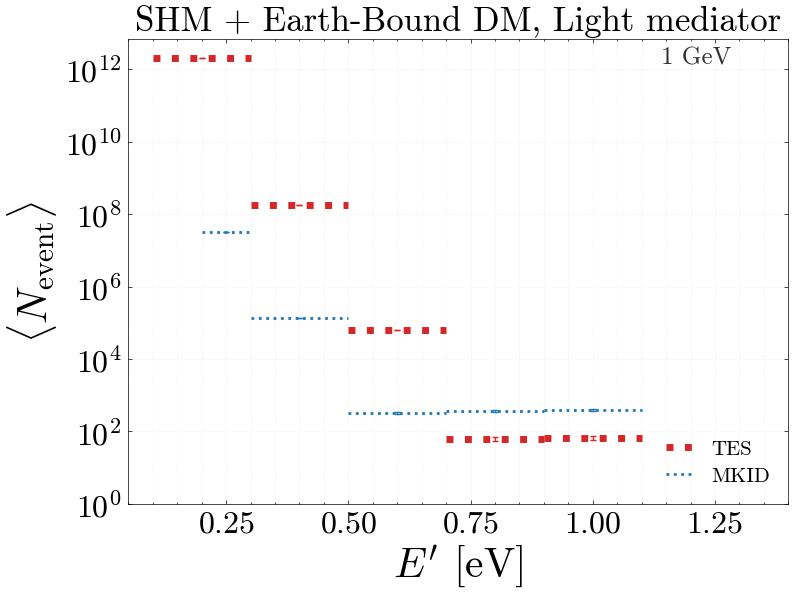

<Axes: title={'center': 'SHM + Earth-Bound DM, Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [34]:
signal_figure(q='2', eta='Bound', masses = ("3"))

## Bound — fine binning

  saved results/final/signal/Bound/heavy/TES-R10_MKID-R9.pdf


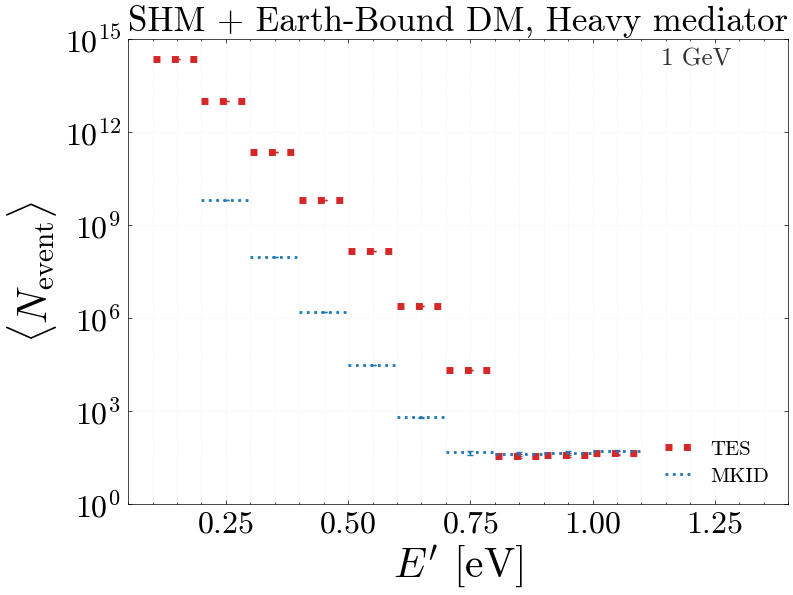

<Axes: title={'center': 'SHM + Earth-Bound DM, Heavy mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [35]:
signal_figure(q='0', eta='Bound', masses = ("3"), tes_nbins=10, mkid_nbins=9)

  saved results/final/signal/Bound/light/TES-R10_MKID-R9.pdf


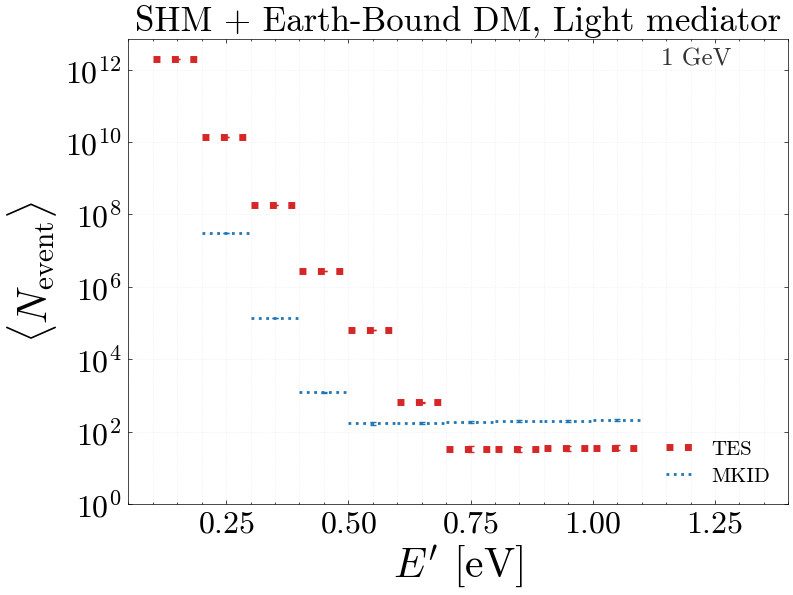

<Axes: title={'center': 'SHM + Earth-Bound DM, Light mediator'}, xlabel="$E'$ [eV]", ylabel='$\\langle N_{\\text{event}} \\rangle$'>

In [36]:
signal_figure(q='2', eta='Bound', masses = ("3"), tes_nbins=10, mkid_nbins=9)

# Response functions $\mathcal{R}_{\left[E_i, E_{i + 1}\right]}(v_{\text{min}})$

Python port of `09_response_function_plot.wl`: for each configuration, overlay **all** energy bins' response functions over their **full** v_min domain (read from the CSVs exported by `09b_response_function_export.wl`). Saved under `results/final/response/<detector>/<heavy|light>/R<nbins>/M<mass>.pdf`.

In [37]:
# (material, q, nbins) response-function CSVs exported by 09b (full v_min domain).
RESPONSE_GRID = {
    "TES":  [("0", 5), ("0", 10), ("2", 5), ("2", 10)],
    "MKID": [("0", 5), ("0", 9),  ("2", 5), ("2", 9)],
}


def response_figure(detector, q, mass, nbins, save=True, show=True, outdir=OUTDIR):
    """Overlay every energy bin's response function R_bin(v_min) for one config.

    The Python counterpart of 09_response_function_plot.wl: reads the full-domain
    CSV that 09b_response_function_export.wl wrote (R_bin*kg, i.e. [kg^-1]) and
    overlays all bins on a log-log axis, coloured by bin.
    """
    name = f"{MATERIAL[detector]}_q{q}M{mass}_R{nbins}"
    path = MATH_OUTPUT / detector / "response_functions_csv" / f"{name}.csv"
    if not path.exists():
        print(f"  skip {detector} q{q} M{mass} R{nbins}: no CSV ({name}); run 09b export first")
        return None
    with open(path) as f:
        header = next(csv.reader(f))
    data = np.genfromtxt(path, delimiter=",", skip_header=1)
    v = data[:, 0]
    # cmr10 has no en-dash glyph -> use a hyphen in the bin labels
    labels = [lab.replace("–", "-").replace("—", "-") for lab in header[1:]]
    R = data[:, 1:]

    # Normalize by the order of magnitude of the peak response and show it in the
    # y-axis label (same convention as the eta figures).
    peak = float(np.nanmax(R))
    r_exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
    norm = 10.0 ** r_exp

    fig, ax = plt.subplots(figsize=(8, 6))
    # truncate the bright (yellow) end: it washes out on projectors. Line
    # styles carry the rest of the distinction, so a darker sub-range is fine.
    colors = plt.cm.cividis(np.linspace(0.0, 0.6, len(labels)))
    # cycle line styles too, so bins are distinguished without relying on colour
    ls_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)),
                (0, (1, 1)), (0, (3, 1, 1, 1, 1, 1)), (0, (5, 2)), (0, (2, 2))]
    for j, lab in enumerate(labels):
        ax.plot(v, R[:, j] / norm, color=colors[j],
                ls=ls_cycle[j % len(ls_cycle)], lw=2.0, label=lab)

    ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlim(v.min(), v.max())
    ax.set_ylim(0, None)
    ax.set_xlabel(r'$v_{\text{min}}$ [km s$^{-1}$]', fontsize = 25)
    ax.set_ylabel(rf'$\mathcal{{R}}_{{\left[E_i, E_{{i + 1}}\right]}}$ [$10^{{{r_exp}}}$ kg$^{{-1}}$]', fontsize = 25)
    mediator = {"0": "Heavy", "2": "Light"}.get(q, f"q{q}")
    ax.set_title(rf"{detector}, {mediator} mediator, $m_\chi$ = {MASS_LABELS[mass]}",
                 fontsize=23)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=20)
    ax.legend(fontsize=18, frameon=False,
              title=r"$E'$ bin", title_fontsize=15)
    ax.grid(True, which="both", ls="--", alpha=0.3)

    if save:
        dest = outdir / "response" / detector / mediator.lower() / f"R{nbins}"
        dest.mkdir(parents=True, exist_ok=True)
        out = dest / f"M{mass}.pdf"
        plt.savefig(out, bbox_inches="tight")
        print(f"  saved {out.relative_to(RESULTS_DIR.parent)}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return None


def response_all(detectors=("TES", "MKID"), masses=("1", "2", "3"), save=True, show=False):
    """Generate EVERY response-function figure (one file per config). show=False
    by default so the notebook is not flooded with ~40 inline panels."""
    for det in detectors:
        for q, nbins in RESPONSE_GRID[det]:
            for mass in masses:
                response_figure(det, q, mass, nbins, save=save, show=show)

## Examples (single configs)

  saved results/final/response/TES/heavy/R5/M2.pdf


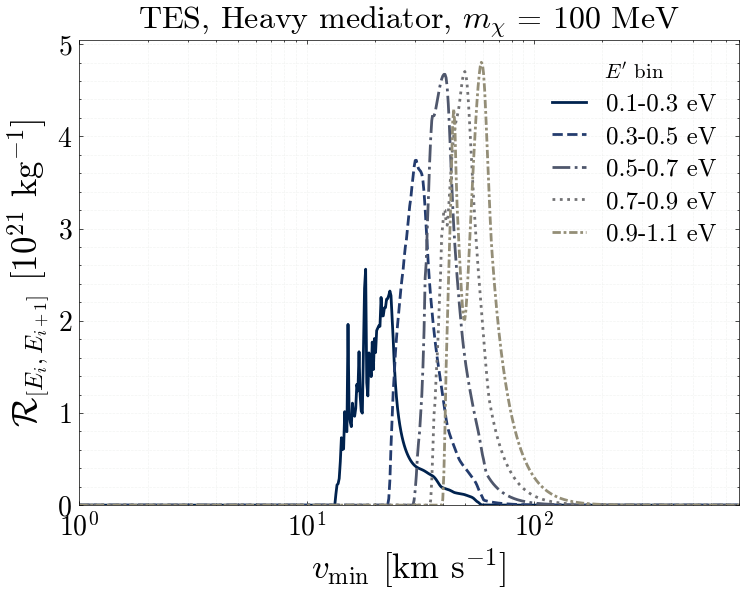

  saved results/final/response/MKID/light/R5/M2.pdf


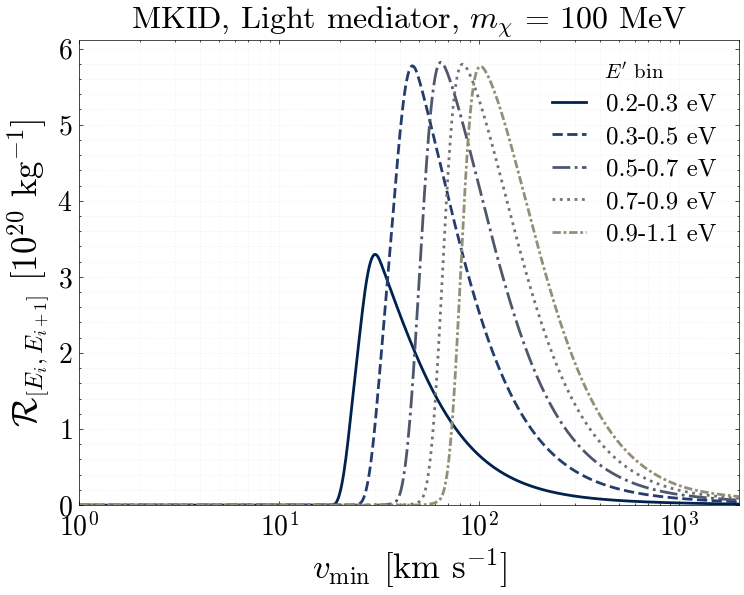

In [38]:
response_figure('TES',  q='0', mass='2', nbins=5)
response_figure('MKID', q='2', mass='2', nbins=5)

## Plot them all (one file per config; not shown inline)

In [39]:
response_all()

  saved results/final/response/TES/heavy/R5/M1.pdf
  saved results/final/response/TES/heavy/R5/M2.pdf
  saved results/final/response/TES/heavy/R5/M3.pdf
  saved results/final/response/TES/heavy/R10/M1.pdf
  saved results/final/response/TES/heavy/R10/M2.pdf
  saved results/final/response/TES/heavy/R10/M3.pdf
  saved results/final/response/TES/light/R5/M1.pdf
  saved results/final/response/TES/light/R5/M2.pdf
  saved results/final/response/TES/light/R5/M3.pdf
  saved results/final/response/TES/light/R10/M1.pdf
  saved results/final/response/TES/light/R10/M2.pdf
  saved results/final/response/TES/light/R10/M3.pdf
  saved results/final/response/MKID/heavy/R5/M1.pdf
  saved results/final/response/MKID/heavy/R5/M2.pdf
  saved results/final/response/MKID/heavy/R5/M3.pdf
  saved results/final/response/MKID/heavy/R9/M1.pdf
  saved results/final/response/MKID/heavy/R9/M2.pdf
  saved results/final/response/MKID/heavy/R9/M3.pdf
  saved results/final/response/MKID/light/R5/M1.pdf
  saved results/fi

# Differential response kernel $d\mathcal{R}/d\omega'$

Python port of `07_dcurlyRdEprime_plot.wl` (data from `07b_dcurlyRdEprime_export.wl`): per detector and mediator, overlay the three DM masses (colour) at two observed energies $E'$ (opacity: detector threshold vs 1 eV reference) over the full $v_{\min}$ range. Saved under `results/final/dcurlyR/<detector>/<heavy|light>.pdf`.

In [40]:
from matplotlib.lines import Line2D

# DM mass -> colour for the differential-kernel figure.
DCR_MASS_COLOR = {"10": "#0072B2", "100": "#E69F00", "1000": "#009E73"}  # Wong CVD-safe
DCR_MASS_LABEL = {"10": "10 MeV", "100": "100 MeV", "1000": "1 GeV"}


def dcurlyR_figure(detector, q, save=True, show=True, outdir=OUTDIR):
    """Differential response kernel d(curly R)/d omega'(v_min) for one detector/mediator.

    Python port of 07_dcurlyRdEprime_plot.wl, reading the CSV exported by
    07b_dcurlyRdEprime_export.wl. Overlays the three DM masses (colour) at two
    observed energies E' (opacity: the bold detector threshold vs the faded 1 eV
    reference) over the full v_min range, on a log-log axis.
    """
    mediator = {"0": "heavy", "2": "light"}.get(q, f"q{q}")
    path = MATH_OUTPUT / detector / "dcurlyRdEprime_csv" / f"{MATERIAL[detector]}_{mediator}.csv"
    if not path.exists():
        print(f"  skip {detector} {mediator}: no CSV; run 07b export first")
        return None
    with open(path) as f:
        header = next(csv.reader(f))
    data = np.genfromtxt(path, delimiter=",", skip_header=1)
    v = data[:, 0]
    # normalize by the peak order of magnitude (shown in the y-axis label)
    peak = float(np.nanmax(data[:, 1:]))
    r_exp = int(np.floor(np.log10(peak))) if peak > 0 else 0
    norm = 10.0 ** r_exp

    fig, ax = plt.subplots(figsize=(8, 6))
    ebold = None
    for j, h in enumerate(header[1:], start=1):
        mass, en = h.split("MeV_")
        en = en.replace("eV", "")
        bold = (en != "1")
        if bold:
            ebold = en
        ax.plot(v, data[:, j] / norm, color=DCR_MASS_COLOR[mass], lw=2.0,
                ls="-" if bold else "--",
                label=DCR_MASS_LABEL[mass] if bold else None)

    ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlim(v.min(), v.max())
    ax.set_ylim(0, None)
    ax.set_xlabel(r"$v_{\text{min}}$ [km s$^{-1}$]", fontsize=30)
    ax.set_ylabel(rf"d$\mathcal{{R}}/$d$E'$  [$10^{{{r_exp}}}$ kg$^{{-1}}$ eV$^{{-1}}$]", fontsize=22)
    ax.set_title(rf"{detector}, {mediator.capitalize()} mediator", fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=20)
    ax.tick_params(axis="both", which="minor", labelsize=20)

    # two legends: DM mass (colour) and observed energy E' (opacity).
    leg_mass = ax.legend(loc="upper right", fontsize=20, frameon=False,
                         title=r"$m_\chi$", title_fontsize=20)
    ax.add_artist(leg_mass)
    e_handles = [Line2D([], [], color="0.2", lw=1.6, ls="-"),
                 Line2D([], [], color="0.2", lw=1.6, ls="--")]
    ax.legend(e_handles, [rf"$E'$ = {ebold} eV", r"$E'$ = 1 eV"],
              loc="upper left", fontsize=20, frameon=False)
    ax.grid(True, which="both", ls="--", alpha=0.3)

    if save:
        dest = outdir / "dcurlyR" / detector
        dest.mkdir(parents=True, exist_ok=True)
        out = dest / f"{mediator}.pdf"
        plt.savefig(out, bbox_inches="tight")
        print(f"  saved {out.relative_to(RESULTS_DIR.parent)}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return None


def dcurlyR_all(detectors=("TES", "MKID"), save=True, show=True):
    """All four differential-kernel figures (detector x mediator)."""
    for det in detectors:
        for q in ("0", "2"):
            dcurlyR_figure(det, q, save=save, show=show)

## All four (TES/MKID x heavy/light)

  saved results/final/dcurlyR/TES/heavy.pdf


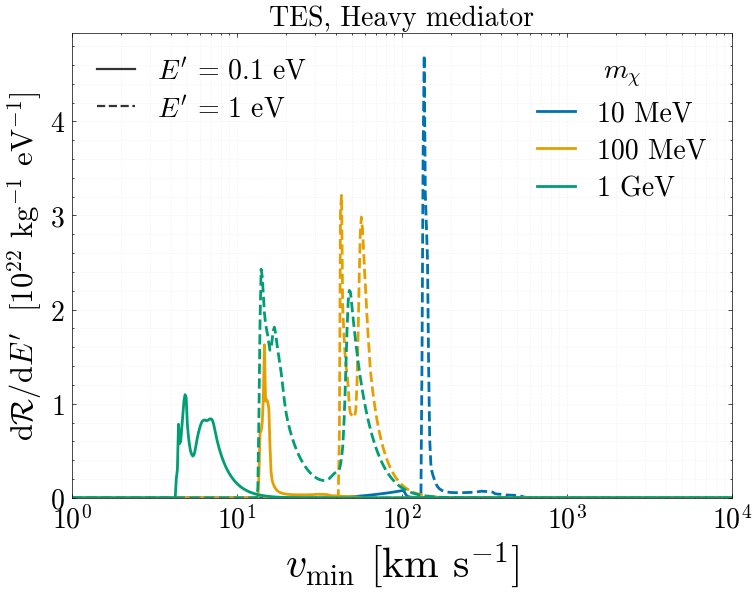

  saved results/final/dcurlyR/TES/light.pdf


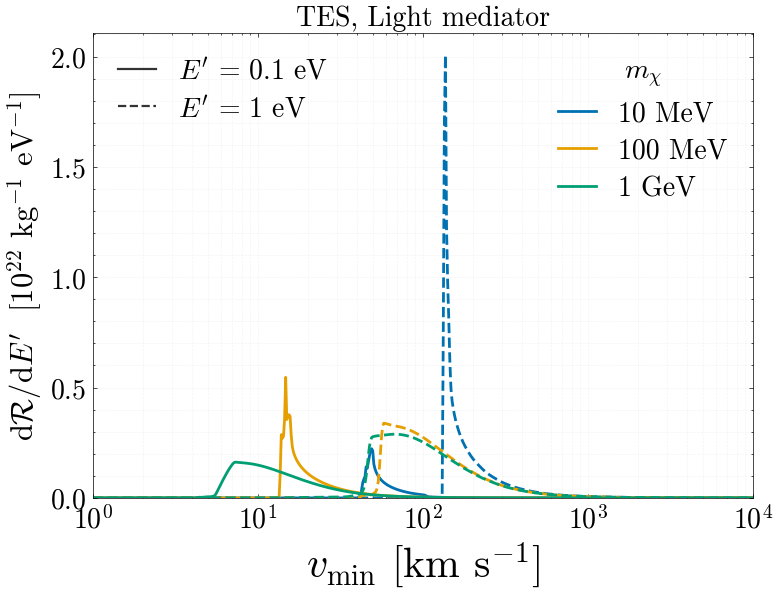

  saved results/final/dcurlyR/MKID/heavy.pdf


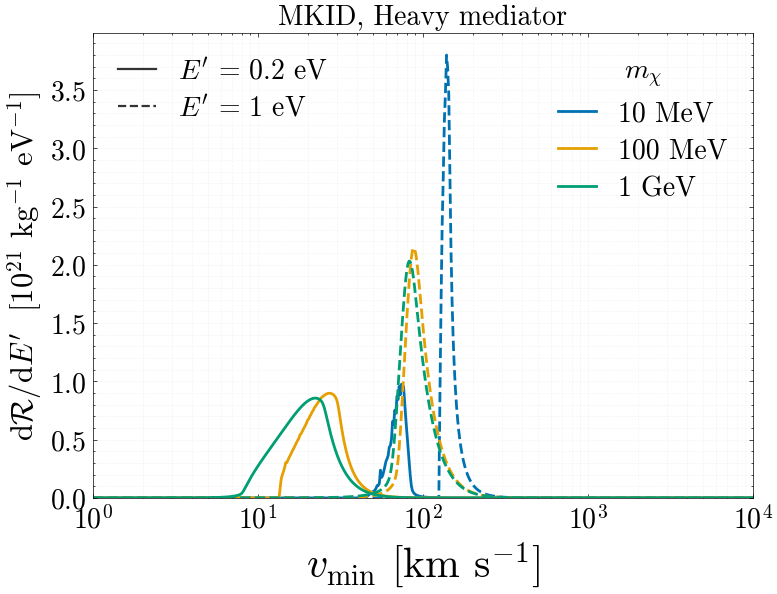

  saved results/final/dcurlyR/MKID/light.pdf


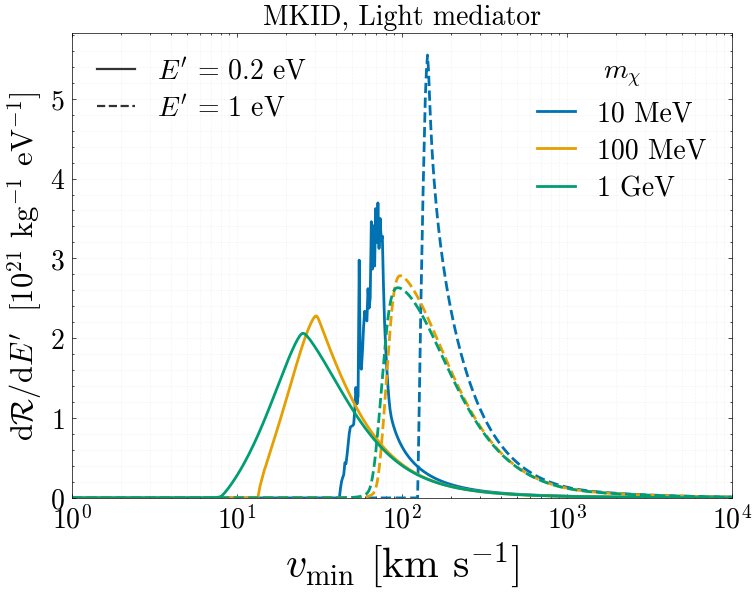

In [41]:
dcurlyR_all()